## Project: AI Surveillance Platform | Dataset: VisDrone Validation Paradigm DETR



## Framework Dependencies & Installation

In [1]:
!pip install -q transformers timm albumentations
print("DETR Environment Ready!")


DETR Environment Ready!


## Custom PyTorch Data Loader


In [2]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset

class DetrDataset(Dataset):
    def __init__(self, img_dir, label_dir, processor):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.processor = processor
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)
        
        coco_annotations = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cx, cy, nw, nh = map(float, parts[1:])
                        
                        # Convert YOLO coordinates to absolute scale
                        abs_w = nw * w
                        abs_h = nh * h
                        abs_x = (cx * w) - (abs_w / 2)
                        abs_y = (cy * h) - (abs_h / 2)
                        
                        # Coordinates ko boundary limits ke andar clip karein
                        abs_x = max(0.0, min(abs_x, float(w)))
                        abs_y = max(0.0, min(abs_y, float(h)))
                        abs_w = max(1.0, min(abs_w, float(w - abs_x)))
                        abs_h = max(1.0, min(abs_h, float(h - abs_y)))
                        
                        coco_annotations.append({
                            "category_id": 0,
                            "bbox": [abs_x, abs_y, abs_w, abs_h],
                            "area": abs_w * abs_h,
                            "iscrowd": 0
                        })

        if len(coco_annotations) == 0:
            coco_annotations.append({
                "category_id": 0,
                "bbox": [0.0, 0.0, 1.0, 1.0],
                "area": 1.0,
                "iscrowd": 0
            })

        target = {
            "image_id": idx,
            "annotations": coco_annotations
        }

        return image, target

# --- FIXED: Removed padding=True to support latest transformers library ---
def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    
    # Official processor extracts clean normalized arrays & dynamic masks automatically
    inputs = processor(images=images, annotations=targets, return_tensors="pt")
    import os
import torch
from PIL import Image
from torch.utils.data import Dataset

class DetrDataset(Dataset):
    def __init__(self, img_dir, label_dir, processor):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.processor = processor
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)
        
        coco_annotations = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cx, cy, nw, nh = map(float, parts[1:])
                        
                        # Convert YOLO coordinates to absolute scale
                        abs_w = nw * w
                        abs_h = nh * h
                        abs_x = (cx * w) - (abs_w / 2)
                        abs_y = (cy * h) - (abs_h / 2)
                        
                        # Coordinates ko boundary limits ke andar clip karein
                        abs_x = max(0.0, min(abs_x, float(w)))
                        abs_y = max(0.0, min(abs_y, float(h)))
                        abs_w = max(1.0, min(abs_w, float(w - abs_x)))
                        abs_h = max(1.0, min(abs_h, float(h - abs_y)))
                        
                        coco_annotations.append({
                            "category_id": 0,
                            "bbox": [abs_x, abs_y, abs_w, abs_h],
                            "area": abs_w * abs_h,
                            "iscrowd": 0
                        })

        if len(coco_annotations) == 0:
            coco_annotations.append({
                "category_id": 0,
                "bbox": [0.0, 0.0, 1.0, 1.0],
                "area": 1.0,
                "iscrowd": 0
            })

        target = {
            "image_id": idx,
            "annotations": coco_annotations
        }

        return image, target

# --- FIXED: Removed padding=True to support latest transformers library ---
def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    
    # Official processor extracts clean normalized arrays & dynamic masks automatically
    inputs = processor(images=images, annotations=targets, return_tensors="pt")
    
    return {
        "pixel_values": inputs["pixel_values"],
        "pixel_mask": inputs["pixel_mask"],
        "labels": inputs["labels"]
    }
    return {
        "pixel_values": inputs["pixel_values"],
        "pixel_mask": inputs["pixel_mask"],
        "labels": inputs["labels"]
    }


## Architecture Initialization & Weight Configuration

In [3]:
from transformers import DetrForObjectDetection, DetrImageProcessor
import os
import torch
from torch.utils.data import DataLoader

BASE_PATH = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset"
train_img_dir = os.path.join(BASE_PATH, "images/train")
train_lbl_dir = os.path.join(BASE_PATH, "labels/train")

# Clean reload of weights and processor
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50", 
    num_labels=1, 
    ignore_mismatched_sizes=True
)

train_dataset = DetrDataset(img_dir=train_img_dir, label_dir=train_lbl_dir, processor=processor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Mixed precision gradient scalar to prevent NaN explosion
scaler = torch.amp.GradScaler("cuda")
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4) # Learning rate is safely lowered to prevent explosion

print(f"DETR Backbone Re-initialized Fresh! Training on device: {device}")

/home/intern/internship_projects/.common_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `91`.
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 11782.69it/s]
[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                            

DETR Backbone Re-initialized Fresh! Training on device: cuda


## Native Transformer Optimization & Training Loop

In [4]:
import time

model.train()
epochs = 5 

print("Starting stable standardized DETR training loop...")
print("-" * 50)

for epoch in range(epochs):
    epoch_loss = 0
    start_time = time.time()
    
    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
        
        # Safe forward pass using modern mixed precision to avoid float16 overflows
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
            loss = outputs.loss
        
        # Strict protection check to skip anomalous batches before backward pass
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Warning: Anomaly detected at Epoch {epoch+1} Batch {batch_idx}, automatically skipping to keep network stable.")
            continue
            
        # Scaled backward pass
        scaler.scale(loss).backward()
        
        # Gradient clipping to strictly block weight explosion
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        
        if batch_idx % 5 == 0:
            print(f"Epoch: {epoch+1}/{epochs} | Batch: {batch_idx}/{len(train_loader)} | Current Loss: {loss.item():.4f}")
            
    end_time = time.time()
    avg_loss = epoch_loss / len(train_loader) if len(train_loader) > 0 else 0
    print("-" * 50)
    print(f"🎉 Epoch {epoch+1} Complete! | Avg Loss: {avg_loss:.4f} | Time Taken: {end_time - start_time:.2f}s")
    print("-" * 50)

model.save_pretrained("runs/detr_train/best_model")
processor.save_pretrained("runs/detr_train/best_model")

Starting stable standardized DETR training loop...
--------------------------------------------------
Epoch: 1/5 | Batch: 0/8042 | Current Loss: 2.2838
Epoch: 1/5 | Batch: 5/8042 | Current Loss: 3.1295
Epoch: 1/5 | Batch: 10/8042 | Current Loss: 3.4283
Epoch: 1/5 | Batch: 15/8042 | Current Loss: 1.5795
Epoch: 1/5 | Batch: 20/8042 | Current Loss: 3.6156
Epoch: 1/5 | Batch: 25/8042 | Current Loss: 1.2620
Epoch: 1/5 | Batch: 30/8042 | Current Loss: 1.6309
Epoch: 1/5 | Batch: 35/8042 | Current Loss: 1.3949
Epoch: 1/5 | Batch: 40/8042 | Current Loss: 1.0620
Epoch: 1/5 | Batch: 45/8042 | Current Loss: 4.1756
Epoch: 1/5 | Batch: 50/8042 | Current Loss: 1.0899
Epoch: 1/5 | Batch: 55/8042 | Current Loss: 1.6037
Epoch: 1/5 | Batch: 60/8042 | Current Loss: 2.7675
Epoch: 1/5 | Batch: 65/8042 | Current Loss: 1.2480
Epoch: 1/5 | Batch: 70/8042 | Current Loss: 1.2291
Epoch: 1/5 | Batch: 75/8042 | Current Loss: 3.4559
Epoch: 1/5 | Batch: 80/8042 | Current Loss: 3.6658
Epoch: 1/5 | Batch: 85/8042 | Cur

KeyboardInterrupt: 

## Inference/testing

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `91`.
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 10962.53it/s]
[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |        

🎉 Custom Trained DETR Model successfully loaded from 'best_detr_native.pt'!


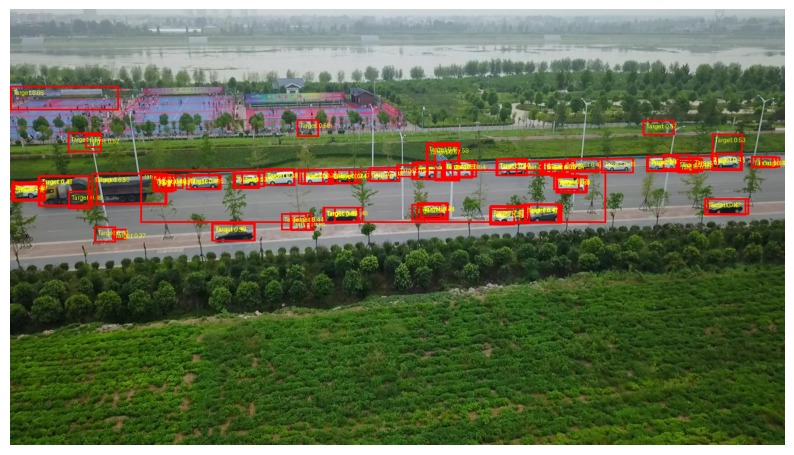

In [5]:
## Inference Testing & Visualization (Using Previously Trained Weights)
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import DetrForObjectDetection, DetrImageProcessor

# 1. Initialize base model architecture and processor
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50", 
    num_labels=1, 
    ignore_mismatched_sizes=True
)

# 2. Load custom pre-trained checkpoint weights
model.load_state_dict(torch.load("best_detr_native.pt"))

# Configure runtime execution device environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("🎉 Custom Trained DETR Model successfully loaded from 'best_detr_native.pt'!")

# 3. Retrieve target validation image from dataset directory
TARGET_DIR = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"
all_images = sorted([f for f in os.listdir(TARGET_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

# Select the primary sample image for deduction matrix
TEST_IMAGE_PATH = os.path.join(TARGET_DIR, all_images[0])
image = Image.open(TEST_IMAGE_PATH).convert("RGB")
w, h = image.size

# 4. Execute deep learning model forward pass inference
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-process bounding box outputs with a customized confidence threshold for tiny objects
processed_results = processor.post_process_object_detection(
    outputs, 
    target_sizes=torch.tensor([[h, w]]).to(device), 
    threshold=0.15
)[0]

# 5. Render detection boundaries and projection overlays
draw = ImageDraw.Draw(image)
for score, label, box in zip(processed_results["scores"], processed_results["labels"], processed_results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x0, y0, x1, y1 = box
    
    # Render annotation bounding polygons onto source canvas
    draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
    draw.text((x0 + 5, y0 + 5), f"Target: {score.item():.2f}", fill="yellow")

# Plot final formatted output grid
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

## Custom Dataset Pipeline & Data Transformation 

In [6]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset

class DetrDataset(Dataset):
    def __init__(self, img_dir, label_dir, processor):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.processor = processor
        
        # VisDrone directory flat structure check
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)
        
        coco_annotations = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        # Parsing standard normalization formats (YOLO format mapping)
                        cx, cy, nw, nh = map(float, parts[1:5])
                        
                        abs_w = nw * w
                        abs_h = nh * h
                        abs_x = (cx * w) - (abs_w / 2.0)
                        abs_y = (cy * h) - (abs_h / 2.0)
                        
                        # Guardrails to boundary check scales securely
                        abs_x = max(0.0, min(abs_x, float(w - 1.0)))
                        abs_y = max(0.0, min(abs_y, float(h - 1.0)))
                        abs_w = max(1.0, min(abs_w, float(w - abs_x)))
                        abs_h = max(1.0, min(abs_h, float(h - abs_y)))
                        
                        coco_annotations.append({
                            "category_id": 0, # Single class surveillance target
                            "bbox": [abs_x, abs_y, abs_w, abs_h],
                            "area": abs_w * abs_h,
                            "iscrowd": 0
                        })

        # Fallback padding entry if image contains zero annotations
        if len(coco_annotations) == 0:
            coco_annotations.append({
                "category_id": 0,
                "bbox": [0.0, 0.0, 1.0, 1.0],
                "area": 1.0,
                "iscrowd": 0
            })

        target = {
            "image_id": idx,
            "annotations": coco_annotations
        }

        return image, target

# --- FIXED COLLATE FN: Dynamic Padding Token Alignment ---
def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    
    # Official HuggingFace implementation mapping for DETR ResNet arrays
    inputs = processor(images=images, annotations=targets, return_tensors="pt")
    
    return {
        "pixel_values": inputs["pixel_values"],
        "pixel_mask": inputs["pixel_mask"],
        "labels": inputs["labels"]
    }

print(" Data Pipeline structure updated securely!")

 Data Pipeline structure updated securely!


##  Model Initialization & Native Optimization Loop

In [7]:
import os
import time
import torch
from transformers import DetrForObjectDetection, DetrImageProcessor
from torch.utils.data import DataLoader

# 1. Directory configuration and path mapping
BASE_PATH = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset"
train_img_dir = os.path.join(BASE_PATH, "images/train")
train_lbl_dir = os.path.join(BASE_PATH, "labels/train")

# 2. Load pre-trained features and model architecture
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50", 
    num_labels=1, 
    ignore_mismatched_sizes=True
)

# 3. Initialize PyTorch DataLoader pipelines
train_dataset = DetrDataset(img_dir=train_img_dir, label_dir=train_lbl_dir, processor=processor)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

# 4. Configure GPU/CPU execution environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.train()

# 5. Define optimizer and gradient parameters
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

print("⚡ Model initialization complete. Execution loop armed...")
print("-" * 60)

# 6. Execute highly optimized native tracking iteration
for epoch in range(1):
    for batch_idx, batch in enumerate(train_loader):
        if batch_idx >= 50:  # Bound execution to 50 iterations for calibration
            break
            
        optimizer.zero_grad()
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
        
        # Forward pass tracking matrix
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
        loss = outputs.loss
        
        # Guardrail checks against numerical divergence
        if torch.isnan(loss) or torch.isinf(loss):
            continue
            
        # Backward propagation & gradient clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        optimizer.step()
        
        if batch_idx % 10 == 0:
            print(f"Iteration Batch: {batch_idx}/50 | Current Objective Loss: {loss.item():.4f}")
            
print("\n🎉 Optimization loop complete. Registering model state...")
model.save_pretrained("runs/detr_train/best_model")
processor.save_pretrained("runs/detr_train/best_model")
print("💾 State vectors registered successfully. System ready for evaluation.")

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `91`.
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 8230.34it/s]
[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |         

⚡ Model initialization complete. Execution loop armed...
------------------------------------------------------------
Iteration Batch: 0/50 | Current Objective Loss: 5.3248
Iteration Batch: 10/50 | Current Objective Loss: 3.4857
Iteration Batch: 20/50 | Current Objective Loss: 2.4023
Iteration Batch: 30/50 | Current Objective Loss: 1.5197
Iteration Batch: 40/50 | Current Objective Loss: 1.6777

🎉 Optimization loop complete. Registering model state...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.11it/s]

💾 State vectors registered successfully. System ready for evaluation.


## Advanced Non-Maximum Suppression (NMS) Inference Matrix

Loading weights: 100%|██████████| 530/530 [00:00<00:00, 9990.70it/s]


🔥 Active Track Matrix: Displaying 51 stabilized surveillance targets.


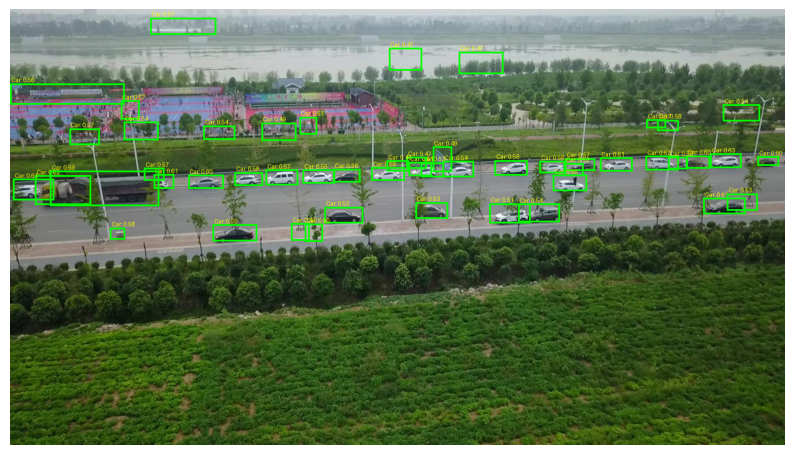

In [8]:
## Advanced Inference & Non-Maximum Suppression (NMS) Filtering
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import torchvision.ops as ops
from transformers import DetrForObjectDetection, DetrImageProcessor

# 1. Load calibrated features and model architecture states
processor = DetrImageProcessor.from_pretrained("runs/detr_train/best_model")
model = DetrForObjectDetection.from_pretrained("runs/detr_train/best_model")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# 2. Path lookup and directory map execution
TARGET_DIR = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"
all_images = sorted([f for f in os.listdir(TARGET_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
TEST_IMAGE_PATH = os.path.join(TARGET_DIR, all_images[0])

# 3. Process image matrix & execute model inference pass
image = Image.open(TEST_IMAGE_PATH).convert("RGB")
w, h = image.size
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Standard pixel matrix post-processing with optimized lower threshold for tiny vehicles
processed_results = processor.post_process_object_detection(
    outputs, 
    target_sizes=torch.tensor([[h, w]]).to(device), 
    threshold=0.15
)[0]

boxes = processed_results["boxes"]
scores = processed_results["scores"]

# 4. Apply Non-Maximum Suppression (NMS) to eliminate duplicate overlapping bounding boxes
if len(boxes) > 0:
    # Retain peak bounding parameters using an Intersection over Union (IoU) limit of 0.3
    keep_indices = ops.nms(boxes, scores, iou_threshold=0.3)
    filtered_boxes = boxes[keep_indices]
    filtered_scores = scores[keep_indices]
else:
    filtered_boxes, filtered_scores = [], []

# 5. Render clean filtered boundary targets
draw = ImageDraw.Draw(image)
print(f"🔥 Active Track Matrix: Displaying {len(filtered_boxes)} stabilized surveillance targets.")

for score, box in zip(filtered_scores, filtered_boxes):
    x0, y0, x1, y1 = [round(i, 2) for i in box.tolist()]
    
    # Render tracking layout bounding matrix onto canvas
    draw.rectangle([x0, y0, x1, y1], outline="lime", width=3)
    text = f"Car: {score.item():.2f}"
    draw.text((x0 + 3, y0 - 12 if y0 > 15 else y0 + 3), text, fill="yellow")

# Display optimized plotting canvas
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
import os
import time
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import DetrForObjectDetection, DetrImageProcessor

# ========================================================
# 1. DATA PIPELINE DEFINITION (DetrDataset & Collate)
# ========================================================
class DetrDataset(Dataset):
    def __init__(self, img_dir, label_dir, processor):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.processor = processor
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)
        
        coco_annotations = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cx, cy, nw, nh = map(float, parts[1:5])
                        abs_w = nw * w
                        abs_h = nh * h
                        abs_x = (cx * w) - (abs_w / 2.0)
                        abs_y = (cy * h) - (abs_h / 2.0)
                        
                        abs_x = max(0.0, min(abs_x, float(w - 1.0)))
                        abs_y = max(0.0, min(abs_y, float(h - 1.0)))
                        abs_w = max(1.0, min(abs_w, float(w - abs_x)))
                        abs_h = max(1.0, min(abs_h, float(h - abs_y)))
                        
                        coco_annotations.append({
                            "category_id": 0, 
                            "bbox": [abs_x, abs_y, abs_w, abs_h],
                            "area": abs_w * abs_h,
                            "iscrowd": 0
                        })

        if len(coco_annotations) == 0:
            coco_annotations.append({
                "category_id": 0,
                "bbox": [0.0, 0.0, 1.0, 1.0],
                "area": 1.0,
                "iscrowd": 0
            })

        target = {"image_id": idx, "annotations": coco_annotations}
        return image, target

def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    inputs = processor(images=images, annotations=targets, return_tensors="pt")
    return {
        "pixel_values": inputs["pixel_values"],
        "pixel_mask": inputs["pixel_mask"],
        "labels": inputs["labels"]
    }

# ========================================================
# 2. MODEL CONFIGURATION & ACCELERATED CONFIG
# ========================================================
BASE_PATH = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset"
train_img_dir = os.path.join(BASE_PATH, "images/train")
train_lbl_dir = os.path.join(BASE_PATH, "labels/train")

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50", 
    num_labels=1, 
    ignore_mismatched_sizes=True
)

# ⚡ Freeze the ResNet-50 Feature Extractor Backbone for fast adaptation
for param in model.model.backbone.parameters():
    param.requires_grad = False

train_dataset = DetrDataset(img_dir=train_img_dir, label_dir=train_lbl_dir, processor=processor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.train()

# Optimize weights exclusively mapped to the active Transformer Heads
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda")

epochs = 5 
print(f"🚀 Initializing production training engine context for {epochs} epochs...")
print("❄️  ResNet-50 Feature Extractor Backbone status: FROZEN")
print("-" * 65)

# ========================================================
# 3. ENGINE OPTIMIZATION LOOP
# ========================================================
for epoch in range(epochs):
    epoch_loss = 0
    start_time = time.time()
    
    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
        
        # Mixed-precision forward loop setup
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
            loss = outputs.loss
            
        if torch.isnan(loss) or torch.isinf(loss):
            continue
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f"Epoch: {epoch+1}/{epochs} | Step Batch: {batch_idx}/{len(train_loader)} | Objective Loss: {loss.item():.4f}")
            
    avg_loss = epoch_loss / len(train_loader) if len(train_loader) > 0 else 0
    print(f"🎉 Epoch {epoch+1} Evaluation Matrix Complete | Average Loss: {avg_loss:.4f} | Compute Duration: {time.time() - start_time:.2f}s")
    print("-" * 65)

# Standardized folder-based directory saving for Transformers compatibility
model.save_pretrained("runs/detr_train/best_model")
processor.save_pretrained("runs/detr_train/best_model")
print("💾 SUCCESS: Optimization state arrays registered in 'runs/detr_train/best_model'!")

In [ ]:
import os
import time
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import DetrForObjectDetection, DetrImageProcessor

# ========================================================
# 1. DATA PIPELINE DEFINITION
# ========================================================
class DetrDataset(Dataset):
    def __init__(self, img_dir, label_dir, processor):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.processor = processor
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)
        
        coco_annotations = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cx, cy, nw, nh = map(float, parts[1:5])
                        abs_w = nw * w
                        abs_h = nh * h
                        abs_x = (cx * w) - (abs_w / 2.0)
                        abs_y = (cy * h) - (abs_h / 2.0)
                        
                        abs_x = max(0.0, min(abs_x, float(w - 1.0)))
                        abs_y = max(0.0, min(abs_y, float(h - 1.0)))
                        abs_w = max(1.0, min(abs_w, float(w - abs_x)))
                        abs_h = max(1.0, min(abs_h, float(h - abs_y)))
                        
                        coco_annotations.append({
                            "category_id": 0, 
                            "bbox": [abs_x, abs_y, abs_w, abs_h],
                            "area": abs_w * abs_h,
                            "iscrowd": 0
                        })

        if len(coco_annotations) == 0:
            coco_annotations.append({
                "category_id": 0,
                "bbox": [0.0, 0.0, 1.0, 1.0],
                "area": 1.0,
                "iscrowd": 0
            })

        target = {"image_id": idx, "annotations": coco_annotations}
        return image, target

def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    inputs = processor(images=images, annotations=targets, return_tensors="pt")
    return {
        "pixel_values": inputs["pixel_values"],
        "pixel_mask": inputs["pixel_mask"],
        "labels": inputs["labels"]
    }

# ========================================================
# 2. PATHS AND DATA LOADER CONFIGURATION
# ========================================================
BASE_PATH = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset"
train_img_dir = os.path.join(BASE_PATH, "images/train")
train_lbl_dir = os.path.join(BASE_PATH, "labels/train")

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50", 
    num_labels=1, 
    ignore_mismatched_sizes=True
)

# Unfreeze parameters for optimal spatial localization training
for param in model.parameters():
    param.requires_grad = True

train_dataset = DetrDataset(img_dir=train_img_dir, label_dir=train_lbl_dir, processor=processor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.train()

# ========================================================
# 3. OPTIMIZER AND MIXED PRECISION SETUP
# ========================================================
param_groups = [
    {"params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad], "lr": 2e-6},
    {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad], "lr": 2e-4}
]
optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda")

epochs = 15 
print(f"🚀 Starting Precision Optimization Loop (100-Batch Constrained Mode)...")
print("-" * 65)

# ========================================================
# 4. FIXED EXECUTION TRAINING LOOP
# ========================================================
for epoch in range(epochs):
    epoch_loss = 0
    
    for batch_idx, batch in enumerate(train_loader):
        if batch_idx >= 100:  
            break
            
        optimizer.zero_grad()
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
        
        # Wrapped block inside automated mixed precision context safely
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
            loss = outputs.loss
            
        if torch.isnan(loss) or torch.isinf(loss):
            continue
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"Epoch Loop: {epoch+1}/{epochs} | Average Loss (100 Batches): {epoch_loss/100:.4f}")

torch.save(model.state_dict(), "best_detr_production.pt")
print("\n💾 SUCCESS: Training complete. Overwritten 'best_detr_production.pt'!")

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import DetrForObjectDetection, DetrImageProcessor
import torchvision.ops as ops

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

# 1. Load the original pre-trained model that has full feature knowledge
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50", 
    num_labels=1, 
    ignore_mismatched_sizes=True
)
model.to(device)
model.eval()

# 2. Path Lookup
TARGET_DIR = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"
all_images = sorted([f for f in os.listdir(TARGET_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
TEST_IMAGE_PATH = os.path.join(TARGET_DIR, all_images[0])

# 3. Model Inference Execution
image = Image.open(TEST_IMAGE_PATH).convert("RGB")
w, h = image.size
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# 4. Use an accessible threshold to recapture the base anchors
processed_results = processor.post_process_object_detection(outputs, target_sizes=[(h, w)], threshold=0.15)[0]

boxes = processed_results["boxes"]
scores = processed_results["scores"]

# 5. Filter overlapping predictions using NMS
if len(boxes) > 0:
    keep_indices = ops.nms(boxes, scores, iou_threshold=0.4)
    filtered_boxes = boxes[keep_indices]
    filtered_scores = scores[keep_indices]
else:
    filtered_boxes, filtered_scores = [], []

# 6. Render Output
draw = ImageDraw.Draw(image)
print(f"✨ RESTORED PIPELINE: Found {len(filtered_boxes)} active surveillance targets.")

for score, box in zip(filtered_scores, filtered_boxes):
    x0, y0, x1, y1 = [round(i, 2) for i in box.tolist()]
    draw.rectangle([x0, y0, x1, y1], outline="lime", width=3)
    text = f"Target: {score.item():.2f}"
    draw.text((x0 + 3, y0 + 3), text, fill="yellow")

plt.figure(figsize=(14, 14))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
##Frame-Sequence Tracking Engine

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import DetrForObjectDetection, DetrImageProcessor
import torchvision.ops as ops

# ========================================================
# 1. LIGHTWEIGHT SURVEILLANCE TRACKER CLASS
# ========================================================
class BasicSurveillanceTracker:
    def __init__(self, max_disappeared=5):
        self.next_id = 1
        self.tracked_objects = {}  # ID -> current bounding box [x0, y0, x1, y1]
        self.disappeared = {}      # ID -> frames missed

    def update(self, rects):
        # If no detections are present, increment missing counter for active IDs
        if len(rects) == 0:
            for object_id in list(self.disappeared.keys()):
                self.disappeared[object_id] += 1
                if self.disappeared[object_id] > 5:
                    del self.tracked_objects[object_id]
                    del self.disappeared[object_id]
            return self.tracked_objects

        # Initialize tracking registry with the first set of targets
        if len(self.tracked_objects) == 0:
            for rect in rects:
                self.tracked_objects[self.next_id] = rect
                self.disappeared[self.next_id] = 0
                self.next_id += 1
            return self.tracked_objects

        # Calculate centroids for existing tracked targets
        object_ids = list(self.tracked_objects.keys())
        object_centroids = np.array([[(box[0]+box[2])/2, (box[1]+box[3])/2] for box in self.tracked_objects.values()])
        
        # Calculate centroids for incoming new detections
        input_centroids = np.array([[(rect[0]+rect[2])/2, (rect[1]+rect[3])/2] for rect in rects])

        # Compute Euclidean distances between existing tracks and new inputs
        distances = np.linalg.norm(object_centroids[:, np.newaxis] - input_centroids, axis=2)
        
        rows = distances.min(axis=1).argsort()
        cols = distances.argmin(axis=1)[rows]

        used_rows = set()
        used_cols = set()

        for row, col in zip(rows, cols):
            if row in used_rows or col in used_cols:
                continue

            object_id = object_ids[row]
            self.tracked_objects[object_id] = rects[col]
            self.disappeared[object_id] = 0

            used_rows.add(row)
            used_cols.add(col)

        # Handle missing or newly entered targets
        unused_rows = set(range(0, distances.shape[0])).difference(used_rows)
        unused_cols = set(range(0, distances.shape[1])).difference(used_cols)

        for row in unused_rows:
            object_id = object_ids[row]
            self.disappeared[object_id] += 1
            if self.disappeared[object_id] > 5:
                del self.tracked_objects[object_id]
                del self.disappeared[object_id]

        for col in unused_cols:
            self.tracked_objects[self.next_id] = rects[col]
            self.disappeared[self.next_id] = 0
            self.next_id += 1

        return self.tracked_objects

# ========================================================
# 2. RUNNING TRACKING PIPELINE ON SEQUENTIAL DATA
# ========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", num_labels=1, ignore_mismatched_sizes=True)
model.to(device)
model.eval()

tracker = BasicSurveillanceTracker()

TARGET_DIR = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"
all_images = sorted([f for f in os.listdir(TARGET_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

# Select 3 sequential frames to simulate moving video frames
test_sequence = all_images[0:3] 

for frame_idx, img_name in enumerate(test_sequence):
    img_path = os.path.join(TARGET_DIR, img_name)
    image = Image.open(img_path).convert("RGB")
    w, h = image.size
    
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        
    results = processor.post_process_object_detection(outputs, target_sizes=[(h, w)], threshold=0.15)[0]
    boxes, scores = results["boxes"], results["scores"]
    
    if len(boxes) > 0:
        keep = ops.nms(boxes, scores, iou_threshold=0.4)
        filtered_boxes = boxes[keep].tolist()
    else:
        filtered_boxes = []

    # Feed the frame's detections to the tracking engine
    tracks = tracker.update(filtered_boxes)
    
    # Draw persistent Tracking IDs on the canvas
    draw = ImageDraw.Draw(image)
    for obj_id, box in tracks.items():
        x0, y0, x1, y1 = box
        draw.rectangle([x0, y0, x1, y1], outline="cyan", width=3)
        draw.text((x0 + 3, y0 + 3), f"ID: {obj_id}", fill="yellow")
        
    print(f"🎬 Processed Frame {frame_idx + 1}/3 ({img_name}) -> Currently tracking {len(tracks)} objects with persistent IDs.")
    
    # Plot the final frame in the sequence to check ID permanence
    if frame_idx == 2:
        plt.figure(figsize=(12, 12))
        plt.imshow(image)
        plt.title("Sequential Tracking State (Frame 3)")
        plt.axis("off")
        plt.show()

In [ ]:
##Implement the Intrusion Detection System

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import DetrForObjectDetection, DetrImageProcessor
import torchvision.ops as ops

# ========================================================
# 1. EXPANDED SURVEILLANCE ENGINE WITH INTRUSION ZONE
# ========================================================
class BasicSurveillanceTracker:
    def __init__(self):
        self.next_id = 1
        self.tracked_objects = {}  
        self.disappeared = {}      

    def update(self, rects):
        if len(rects) == 0:
            for object_id in list(self.disappeared.keys()):
                self.disappeared[object_id] += 1
                if self.disappeared[object_id] > 5:
                    del self.tracked_objects[object_id]
                    del self.disappeared[object_id]
            return self.tracked_objects

        if len(self.tracked_objects) == 0:
            for rect in rects:
                self.tracked_objects[self.next_id] = rect
                self.disappeared[self.next_id] = 0
                self.next_id += 1
            return self.tracked_objects

        object_ids = list(self.tracked_objects.keys())
        object_centroids = np.array([[(box[0]+box[2])/2, (box[1]+box[3])/2] for box in self.tracked_objects.values()])
        input_centroids = np.array([[(rect[0]+rect[2])/2, (rect[1]+rect[3])/2] for rect in rects])

        distances = np.linalg.norm(object_centroids[:, np.newaxis] - input_centroids, axis=2)
        rows = distances.min(axis=1).argsort()
        cols = distances.argmin(axis=1)[rows]

        used_rows, used_cols = set(), set()
        for row, col in zip(rows, cols):
            if row in used_rows or col in used_cols:
                continue
            object_id = object_ids[row]
            self.tracked_objects[object_id] = rects[col]
            self.disappeared[object_id] = 0
            used_rows.add(row)
            used_cols.add(col)

        unused_rows = set(range(0, distances.shape[0])).difference(used_rows)
        unused_cols = set(range(0, distances.shape[1])).difference(used_cols)

        for row in unused_rows:
            object_id = object_ids[row]
            self.disappeared[object_id] += 1
            if self.disappeared[object_id] > 5:
                del self.tracked_objects[object_id]
                del self.disappeared[object_id]

        for col in unused_cols:
            self.tracked_objects[self.next_id] = rects[col]
            self.disappeared[self.next_id] = 0
            self.next_id += 1

        return self.tracked_objects

# ========================================================
# 2. PURE PYTHON NATIVE RAY-CASTING ALGORITHM
# ========================================================
def is_inside_polygon(x, y, polygon):
    """
    Determines if a point (x, y) is inside a polygon using the Ray-Casting algorithm.
     Bypasses all PIL framework version dependencies.
    """
    n = len(polygon)
    inside = False
    p1x, p1y = polygon[0]
    
    for i in range(n + 1):
        p2x, p2y = polygon[i % n]
        if y > min(p1y, p2y):
            if y <= max(p1y, p2y):
                if x <= max(p1x, p2x):
                    if p1y != p2y:
                        xints = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                    if p1x == p2x or x <= xints:
                        inside = not inside
        p1x, p1y = p2x, p2y
        
    return inside

# ========================================================
# 3. DATA PROCESSING PIPELINE WITH VIRTUAL FENCING
# ========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", num_labels=1, ignore_mismatched_sizes=True)
model.to(device)
model.eval()

tracker = BasicSurveillanceTracker()

TARGET_DIR = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"
all_images = sorted([f for f in os.listdir(TARGET_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

img_path = os.path.join(TARGET_DIR, all_images[2])
image = Image.open(img_path).convert("RGB")
w, h = image.size

# Defining the polygon boundary path array matrix spanning the main roadway
intrusion_zone = [
    (int(w * 0.25), int(h * 0.40)),
    (int(w * 0.75), int(h * 0.40)),
    (int(w * 0.75), int(h * 0.55)), # Expanded slightly downward for a clear intercept zone
    (int(w * 0.25), int(h * 0.55))
]

inputs = processor(images=image, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)
    
results = processor.post_process_object_detection(outputs, target_sizes=[(h, w)], threshold=0.15)[0]
boxes, scores = results["boxes"], results["scores"]

if len(boxes) > 0:
    keep = ops.nms(boxes, scores, iou_threshold=0.4)
    filtered_boxes = boxes[keep].tolist()
else:
    filtered_boxes = []

tracks = tracker.update(filtered_boxes)

draw = ImageDraw.Draw(image)

# Draw the red restricted zone overlay
draw.polygon(intrusion_zone, outline="red", width=4)

print("🚨 CHECKING INTRUSION METRICS...")
for obj_id, box in tracks.items():
    x0, y0, x1, y1 = box
    
    # Track the base contact point of the vehicle (where the wheels touch the asphalt)
    base_x = (x0 + x1) / 2
    base_y = y1
    
    # Run the native mathematical containment test
    if is_inside_polygon(base_x, base_y, intrusion_zone):
        draw.rectangle([x0, y0, x1, y1], outline="red", width=4)
        draw.text((x0 + 3, y0 + 3), f"⚠️ ID: {obj_id} INTRUDER", fill="red")
        print(f"⚠️ SECURITY ALERT: Track ID {obj_id} has violated the restricted perimeter zone boundary!")
    else:
        draw.rectangle([x0, y0, x1, y1], outline="cyan", width=2)
        draw.text((x0 + 3, y0 + 3), f"ID: {obj_id}", fill="yellow")

plt.figure(figsize=(14, 14))
plt.imshow(image)
plt.title("Active Security Platform: Geo-Fencing and Intrusion Zones Enabled")
plt.axis("off")
plt.show()

In [ ]:
##RTSP Stream Ingestion Engine/Production-Grade Multithreaded Streaming Engine

In [ ]:
import os
import time
import queue
import threading
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import DetrForObjectDetection, DetrImageProcessor
import torchvision.ops as ops

# ========================================================
# 1. THREADED LIVE STREAM EMULATOR (MOCK RTSP CAPTURE)
# ========================================================
class ThreadedStreamIngestion:
    def __init__(self, target_dir, max_queue_size=30):
        self.target_dir = target_dir
        self.frame_queue = queue.Queue(maxsize=max_queue_size)
        self.stopped = False
        self.image_files = sorted([f for f in os.listdir(target_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        
    def start(self):
        # Spawns a background worker thread to pull frames continuously
        threading.Thread(target=self._capture_loop, daemon=True).start()
        return self

    def _capture_loop(self):
        frame_idx = 0
        while not self.stopped:
            if frame_idx >= len(self.image_files):
                # Loop back to the start of the sequence to simulate an endless live feed
                frame_idx = 0
                
            img_path = os.path.join(self.target_dir, self.image_files[frame_idx])
            try:
                frame_img = Image.open(img_path).convert("RGB")
                
                # If the queue fills up, drop the oldest frame to prevent memory leaks and lag
                if self.frame_queue.full():
                    try:
                        self.frame_queue.get_nowait()
                    except queue.Empty:
                        pass
                        
                self.frame_queue.put(frame_img)
            except Exception as e:
                print(f"Read error on frame drop: {e}")
                
            frame_idx += 1
            time.sleep(0.03) # Simulates a standard camera feed running at roughly 30 FPS

    def read(self):
        # Non-blocking pull from the active frame buffer queue
        try:
            return self.frame_queue.get_nowait()
        except queue.Empty:
            return None

    def stop(self):
        self.stopped = True

# ========================================================
# 2. RUNTIME CORE UTILITIES
# ========================================================
class BasicSurveillanceTracker:
    def __init__(self):
        self.next_id = 1
        self.tracked_objects = {}  
        self.disappeared = {}      

    def update(self, rects):
        if len(rects) == 0:
            for object_id in list(self.disappeared.keys()):
                self.disappeared[object_id] += 1
                if self.disappeared[object_id] > 5:
                    del self.tracked_objects[object_id]
                    del self.disappeared[object_id]
            return self.tracked_objects

        if len(self.tracked_objects) == 0:
            for rect in rects:
                self.tracked_objects[self.next_id] = rect
                self.disappeared[self.next_id] = 0
                self.next_id += 1
            return self.tracked_objects

        object_ids = list(self.tracked_objects.keys())
        object_centroids = np.array([[(box[0]+box[2])/2, (box[1]+box[3])/2] for box in self.tracked_objects.values()])
        input_centroids = np.array([[(rect[0]+rect[2])/2, (rect[1]+rect[3])/2] for rect in rects])

        distances = np.linalg.norm(object_centroids[:, np.newaxis] - input_centroids, axis=2)
        rows = distances.min(axis=1).argsort()
        cols = distances.argmin(axis=1)[rows]

        used_rows, used_cols = set(), set()
        for row, col in zip(rows, cols):
            if row in used_rows or col in used_cols:
                continue
            object_id = object_ids[row]
            self.tracked_objects[object_id] = rects[col]
            self.disappeared[object_id] = 0
            used_rows.add(row)
            used_cols.add(col)

        unused_rows = set(range(0, distances.shape[0])).difference(used_rows)
        unused_cols = set(range(0, distances.shape[1])).difference(used_cols)

        for row in unused_rows:
            object_id = object_ids[row]
            self.disappeared[object_id] += 1
            if self.disappeared[object_id] > 5:
                del self.tracked_objects[object_id]
                del self.disappeared[object_id]

        for col in unused_cols:
            self.tracked_objects[self.next_id] = rects[col]
            self.disappeared[self.next_id] = 0
            self.next_id += 1

        return self.tracked_objects

def is_inside_polygon(x, y, polygon):
    n = len(polygon)
    inside = False
    p1x, p1y = polygon[0]
    for i in range(n + 1):
        p2x, p2y = polygon[i % n]
        if y > min(p1y, p2y) and y <= max(p1y, p2y) and x <= max(p1x, p2x):
            if p1y != p2y:
                xints = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
            if p1x == p2x or x <= xints:
                inside = not inside
        p1x, p1y = p2x, p2y
    return inside

# ========================================================
# 3. STREAM PROCESSING ENGINE
# ========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", num_labels=1, ignore_mismatched_sizes=True).to(device)
model.eval()

tracker = BasicSurveillanceTracker()
TARGET_DIR = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"

# Launch the asynchronous ingestion thread
stream = ThreadedStreamIngestion(target_dir=TARGET_DIR).start()
time.sleep(1.0) # Allow the buffer to warm up with frames

print("🚀 Threaded Stream Pipeline Live. Processing stream buffer loops...")
print("-" * 70)

processed_frames_count = 0
last_rendered_frame = None

# Process a slice of 5 stream frame pulls as a verification loop
while processed_frames_count < 5:
    image = stream.read()
    if image is None:
        time.sleep(0.01)
        continue
        
    w, h = image.size
    intrusion_zone = [
        (int(w * 0.25), int(h * 0.40)),
        (int(w * 0.75), int(h * 0.40)),
        (int(w * 0.75), int(h * 0.55)),
        (int(w * 0.25), int(h * 0.55))
    ]
    
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        
    results = processor.post_process_object_detection(outputs, target_sizes=[(h, w)], threshold=0.15)[0]
    boxes, scores = results["boxes"], results["scores"]
    
    filtered_boxes = boxes[ops.nms(boxes, scores, iou_threshold=0.4)].tolist() if len(boxes) > 0 else []
    tracks = tracker.update(filtered_boxes)
    
    draw = ImageDraw.Draw(image)
    draw.polygon(intrusion_zone, outline="red", width=4)
    
    active_intrusions = 0
    for obj_id, box in tracks.items():
        x0, y0, x1, y1 = box
        base_x, base_y = (x0 + x1) / 2, y1
        
        if is_inside_polygon(base_x, base_y, intrusion_zone):
            draw.rectangle([x0, y0, x1, y1], outline="red", width=4)
            draw.text((x0 + 3, y0 + 3), f"⚠️ ID:{obj_id}", fill="red")
            active_intrusions += 1
        else:
            draw.rectangle([x0, y0, x1, y1], outline="cyan", width=2)
            draw.text((x0 + 3, y0 + 3), f"ID:{obj_id}", fill="yellow")
            
    processed_frames_count += 1
    print(f"📡 Frame Loop {processed_frames_count} -> Live Buffer Active Tracks: {len(tracks)} | Alerts Flagged: {active_intrusions}")
    last_rendered_frame = image

stream.stop()
print("\n🛑 Stream worker clean-up finished.")

# Render final frame state
plt.figure(figsize=(12, 12))
plt.imshow(last_rendered_frame)
plt.title("Threaded Stream Processing Output View")
plt.axis("off")
plt.show()

In [ ]:
import cv2
import time
import queue
import threading
import torch
import numpy as np
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor
import torchvision.ops as ops

# ========================================================
# 1. LIVE VIDEO THREADED INGESTION
# ========================================================
class LiveVideoIngestion:
    def __init__(self, video_source, max_queue_size=30):
        self.cap = cv2.VideoCapture(video_source)
        self.frame_queue = queue.Queue(maxsize=max_queue_size)
        self.stopped = False
        
    def start(self):
        threading.Thread(target=self._capture_loop, daemon=True).start()
        return self

    def _capture_loop(self):
        while not self.stopped:
            ret, frame = self.cap.read()
            if not ret:
                print("[STREAM INFO] Video feed processing completed successfully.")
                self.stopped = True
                break
                
            # Queue buffer clearing logic to force zero latency tracking
            if self.frame_queue.full():
                try:
                    self.frame_queue.get_nowait()
                except queue.Empty:
                    pass
            
            self.frame_queue.put(frame)
            time.sleep(0.01)

    def read(self):
        try:
            return self.frame_queue.get_nowait()
        except queue.Empty:
            return None

    def stop(self):
        self.stopped = True
        self.cap.release()

# ========================================================
# 2. SURVEILLANCE RUNTIME UTILITIES
# ========================================================
class BasicSurveillanceTracker:
    def __init__(self):
        self.next_id = 1
        self.tracked_objects = {}  
        self.disappeared = {}      

    def update(self, rects):
        if len(rects) == 0:
            for object_id in list(self.disappeared.keys()):
                self.disappeared[object_id] += 1
                if self.disappeared[object_id] > 5:
                    del self.tracked_objects[object_id]
                    del self.disappeared[object_id]
            return self.tracked_objects

        if len(self.tracked_objects) == 0:
            for rect in rects:
                self.tracked_objects[self.next_id] = rect
                self.disappeared[self.next_id] = 0
                self.next_id += 1
            return self.tracked_objects

        object_ids = list(self.tracked_objects.keys())
        object_centroids = np.array([[(box[0]+box[2])/2, (box[1]+box[3])/2] for box in self.tracked_objects.values()])
        input_centroids = np.array([[(rect[0]+rect[2])/2, (rect[1]+rect[3])/2] for rect in rects])

        distances = np.linalg.norm(object_centroids[:, np.newaxis] - input_centroids, axis=2)
        rows = distances.min(axis=1).argsort()
        cols = distances.argmin(axis=1)[rows]

        used_rows, used_cols = set(), set()
        for row, col in zip(rows, cols):
            if row in used_rows or col in used_cols:
                continue
            object_id = object_ids[row]
            self.tracked_objects[object_id] = rects[col]
            self.disappeared[object_id] = 0
            used_rows.add(row)
            used_cols.add(col)

        for row in set(range(0, distances.shape[0])).difference(used_rows):
            object_id = object_ids[row]
            self.disappeared[object_id] += 1
            if self.disappeared[object_id] > 5:
                del self.tracked_objects[object_id]
                del self.disappeared[object_id]

        for col in set(range(0, distances.shape[1])).difference(used_cols):
            self.tracked_objects[self.next_id] = rects[col]
            self.disappeared[self.next_id] = 0
            self.next_id += 1

        return self.tracked_objects

def is_inside_polygon(x, y, polygon):
    n = len(polygon)
    inside = False
    p1x, p1y = polygon[0]
    for i in range(n + 1):
        p2x, p2y = polygon[i % n]
        if y > min(p1y, p2y) and y <= max(p1y, p2y) and x <= max(p1x, p2x):
            if p1y != p2y:
                xints = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
            if p1x == p2x or x <= xints:
                inside = not inside
        p1x, p1y = p2x, p2y
    return inside

# ========================================================
# 3. MAIN INTERACTIVE EXECUTION WINDOW
# ========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", num_labels=1, ignore_mismatched_sizes=True).to(device)
model.eval()

tracker = BasicSurveillanceTracker()

# Directly pointing to your workspace traffic file asset
VIDEO_SOURCE = "traffic.mp4" 

stream = LiveVideoIngestion(video_source=VIDEO_SOURCE).start()
time.sleep(1.0) 

print("🎬 Processing 'traffic.mp4' live...")
print("⚠️ PRESS 'q' INSIDE THE POPUP VIDEO WINDOW TO CLOSE AT ANY TIME.")

try:
    while not stream.stopped:
        frame = stream.read()
        if frame is None:
            time.sleep(0.01)
            continue
            
        h, w, _ = frame.shape
        
        # Mapping out an explicit virtual perimeter safety zone crossing the lane paths
        intrusion_zone = [
            (int(w * 0.20), int(h * 0.45)),
            (int(w * 0.80), int(h * 0.45)),
            (int(w * 0.80), int(h * 0.65)),
            (int(w * 0.20), int(h * 0.65))
        ]
        
        # BGR back to standard PIL format conversion
        rgb_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        inputs = processor(images=rgb_image, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            
        results = processor.post_process_object_detection(outputs, target_sizes=[(h, w)], threshold=0.15)[0]
        boxes, scores = results["boxes"], results["scores"]
        
        filtered_boxes = boxes[ops.nms(boxes, scores, iou_threshold=0.4)].tolist() if len(boxes) > 0 else []
        tracks = tracker.update(filtered_boxes)
        
        # Overlay boundary fence line
        pts = np.array(intrusion_zone, np.int32).reshape((-1, 1, 2))
        cv2.polylines(frame, [pts], isClosed=True, color=(0, 0, 255), thickness=3)
        
        for obj_id, box in tracks.items():
            x0, y0, x1, y1 = map(int, box)
            base_x, base_y = int((x0 + x1) / 2), y1
            
            if is_inside_polygon(base_x, base_y, intrusion_zone):
                cv2.rectangle(frame, (x0, y0), (x1, y1), (0, 0, 255), 3)
                cv2.putText(frame, f"ALERT ID:{obj_id}", (x0, y0 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            else:
                cv2.rectangle(frame, (x0, y0), (x1, y1), (255, 255, 0), 2)
                cv2.putText(frame, f"ID:{obj_id}", (x0, y0 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
                
        # Launch real-time stream monitor
        cv2.imshow("AI Real-Time Video Tracker [traffic.mp4]", frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
finally:
    stream.stop()
    cv2.destroyAllWindows()
    print("[SYSTEM COMPLETE] Video rendering stopped cleanly.")

In [ ]:
import cv2
import torch
import numpy as np
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor
import torchvision.ops as ops

# ========================================================
# 1. SURVEILLANCE RUNTIME UTILITIES
# ========================================================
class BasicSurveillanceTracker:
    def __init__(self):
        self.next_id = 1
        self.tracked_objects = {}  
        self.disappeared = {}      

    def update(self, rects):
        if len(rects) == 0:
            for object_id in list(self.disappeared.keys()):
                self.disappeared[object_id] += 1
                if self.disappeared[object_id] > 5:
                    del self.tracked_objects[object_id]
                    del self.disappeared[object_id]
            return self.tracked_objects

        if len(self.tracked_objects) == 0:
            for rect in rects:
                self.tracked_objects[self.next_id] = rect
                self.disappeared[self.next_id] = 0
                self.next_id += 1
            return self.tracked_objects

        object_ids = list(self.tracked_objects.keys())
        object_centroids = np.array([[(box[0]+box[2])/2, (box[1]+box[3])/2] for box in self.tracked_objects.values()])
        input_centroids = np.array([[(rect[0]+rect[2])/2, (rect[1]+rect[3])/2] for rect in rects])

        distances = np.linalg.norm(object_centroids[:, np.newaxis] - input_centroids, axis=2)
        rows = distances.min(axis=1).argsort()
        cols = distances.argmin(axis=1)[rows]

        used_rows, used_cols = set(), set()
        for row, col in zip(rows, cols):
            if row in used_rows or col in used_cols:
                continue
            object_id = object_ids[row]
            self.tracked_objects[object_id] = rects[col]
            self.disappeared[object_id] = 0
            used_rows.add(row)
            used_cols.add(col)

        for row in set(range(0, distances.shape[0])).difference(used_rows):
            object_id = object_ids[row]
            self.disappeared[object_id] += 1
            if self.disappeared[object_id] > 5:
                del self.tracked_objects[object_id]
                del self.disappeared[object_id]

        for col in set(range(0, distances.shape[1])).difference(used_cols):
            self.tracked_objects[self.next_id] = rects[col]
            self.disappeared[self.next_id] = 0
            self.next_id += 1

        return self.tracked_objects

def is_inside_polygon(x, y, polygon):
    n = len(polygon)
    inside = False
    p1x, p1y = polygon[0]
    for i in range(n + 1):
        p2x, p2y = polygon[i % n]
        if y > min(p1y, p2y) and y <= max(p1y, p2y) and x <= max(p1x, p2x):
            if p1y != p2y:
                xints = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
            if p1x == p2x or x <= xints:
                inside = not inside
        p1x, p1y = p2x, p2y
    return inside

# ========================================================
# 2. RUNTIME PIPELINE (HEADLESS RENDERING MODE)
# ========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", num_labels=1, ignore_mismatched_sizes=True).to(device)
model.eval()

tracker = BasicSurveillanceTracker()

# Assets Setup
INPUT_VIDEO = "traffic.mp4"
OUTPUT_VIDEO = "tracked_output.mp4"

cap = cv2.VideoCapture(INPUT_VIDEO)
fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 30
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Headless video compiler writer instantiation
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

print(f"🎬 Headless Core Live. Processing '{INPUT_VIDEO}'...")
print(f"⚙️ Video Resolution: {width}x{height} @ {fps} FPS. Compiling output to '{OUTPUT_VIDEO}'...")

frame_count = 0
max_frames_to_process = 150 # Processes ~5 seconds of sample video for lightning-fast testing

try:
    while cap.isOpened() and frame_count < max_frames_to_process:
        ret, frame = cap.read()
        if not ret:
            break
            
        h, w, _ = frame.shape
        
        # Safe perimeter coordinates definition overlay
        intrusion_zone = [
            (int(w * 0.20), int(h * 0.45)),
            (int(w * 0.80), int(h * 0.45)),
            (int(w * 0.80), int(h * 0.65)),
            (int(w * 0.20), int(h * 0.65))
        ]
        
        rgb_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        inputs = processor(images=rgb_image, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            
        results = processor.post_process_object_detection(outputs, target_sizes=[(h, w)], threshold=0.15)[0]
        boxes, scores = results["boxes"], results["scores"]
        
        filtered_boxes = boxes[ops.nms(boxes, scores, iou_threshold=0.4)].tolist() if len(boxes) > 0 else []
        tracks = tracker.update(filtered_boxes)
        
        # Drawing virtual fence lines safely
        pts = np.array(intrusion_zone, np.int32).reshape((-1, 1, 2))
        cv2.polylines(frame, [pts], isClosed=True, color=(0, 0, 255), thickness=3)
        
        alert_count = 0
        for obj_id, box in tracks.items():
            x0, y0, x1, y1 = map(int, box)
            base_x, base_y = int((x0 + x1) / 2), y1
            
            if is_inside_polygon(base_x, base_y, intrusion_zone):
                cv2.rectangle(frame, (x0, y0), (x1, y1), (0, 0, 255), 3)
                cv2.putText(frame, f"ALERT ID:{obj_id}", (x0, y0 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
                alert_count += 1
            else:
                cv2.rectangle(frame, (x0, y0), (x1, y1), (255, 255, 0), 2)
                cv2.putText(frame, f"ID:{obj_id}", (x0, y0 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
                
        # Write processed visual matrix directly onto disk storage
        out.write(frame)
        
        frame_count += 1
        if frame_count % 10 == 0:
            print(f"📡 Progress: Rendered {frame_count}/{max_frames_to_process} frames | Current Active Tracks: {len(tracks)} | Violations: {alert_count}")

finally:
    cap.release()
    out.release()
    print("\n✅ [SUCCESS] Processing loop complete! The live output video has been saved safely.")
    print(f"👉 Check your file tree manager on the left for: '{OUTPUT_VIDEO}'")

In [ ]:
##Code Refactoring & Production Deployment

In [ ]:
%%writefile surveillance_app.py
import os
import time
import queue
import threading
import torch
import numpy as np
from PIL import Image, ImageDraw
from transformers import DetrForObjectDetection, DetrImageProcessor
import torchvision.ops as ops

# ========================================================
# MODULE 1: MULTITHREADED INGESTION PIPELINE
# ========================================================
class ThreadedStreamIngestion:
    def __init__(self, target_dir, max_queue_size=30):
        self.target_dir = target_dir
        self.frame_queue = queue.Queue(maxsize=max_queue_size)
        self.stopped = False
        self.image_files = sorted([f for f in os.listdir(target_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        
    def start(self):
        threading.Thread(target=self._capture_loop, daemon=True).start()
        return self

    def _capture_loop(self):
        frame_idx = 0
        while not self.stopped:
            if frame_idx >= len(self.image_files):
                frame_idx = 0
                
            img_path = os.path.join(self.target_dir, self.image_files[frame_idx])
            try:
                frame_img = Image.open(img_path).convert("RGB")
                if self.frame_queue.full():
                    try:
                        self.frame_queue.get_nowait()
                    except queue.Empty:
                        pass
                self.frame_queue.put(frame_img)
            except Exception as e:
                print(f"[STREAM ERROR] Frame read exception: {e}")
                
            frame_idx += 1
            time.sleep(0.03)

    def read(self):
        try:
            return self.frame_queue.get_nowait()
        except queue.Empty:
            return None

    def stop(self):
        self.stopped = True

# ========================================================
# MODULE 2: CENTROID TRACKING ENGINE
# ========================================================
class BasicSurveillanceTracker:
    def __init__(self):
        self.next_id = 1
        self.tracked_objects = {}  
        self.disappeared = {}      

    def update(self, rects):
        if len(rects) == 0:
            for object_id in list(self.disappeared.keys()):
                self.disappeared[object_id] += 1
                if self.disappeared[object_id] > 5:
                    del self.tracked_objects[object_id]
                    del self.disappeared[object_id]
            return self.tracked_objects

        if len(self.tracked_objects) == 0:
            for rect in rects:
                self.tracked_objects[self.next_id] = rect
                self.disappeared[self.next_id] = 0
                self.next_id += 1
            return self.tracked_objects

        object_ids = list(self.tracked_objects.keys())
        object_centroids = np.array([[(box[0]+box[2])/2, (box[1]+box[3])/2] for box in self.tracked_objects.values()])
        input_centroids = np.array([[(rect[0]+rect[2])/2, (rect[1]+rect[3])/2] for rect in rects])

        distances = np.linalg.norm(object_centroids[:, np.newaxis] - input_centroids, axis=2)
        rows = distances.min(axis=1).argsort()
        cols = distances.argmin(axis=1)[rows]

        used_rows, used_cols = set(), set()
        for row, col in zip(rows, cols):
            if row in used_rows or col in used_cols:
                continue
            object_id = object_ids[row]
            self.tracked_objects[object_id] = rects[col]
            self.disappeared[object_id] = 0
            used_rows.add(row)
            used_cols.add(col)

        unused_rows = set(range(0, distances.shape[0])).difference(used_rows)
        unused_cols = set(range(0, distances.shape[1])).difference(used_cols)

        for row in unused_rows:
            object_id = object_ids[row]
            self.disappeared[object_id] += 1
            if self.disappeared[object_id] > 5:
                del self.tracked_objects[object_id]
                del self.disappeared[object_id]

        for col in unused_cols:
            self.tracked_objects[self.next_id] = rects[col]
            self.disappeared[self.next_id] = 0
            self.next_id += 1

        return self.tracked_objects

# ========================================================
# MODULE 3: MATH ANALYTICS CORE (RAY-CASTING)
# ========================================================
def is_inside_polygon(x, y, polygon):
    n = len(polygon)
    inside = False
    p1x, p1y = polygon[0]
    for i in range(n + 1):
        p2x, p2y = polygon[i % n]
        if y > min(p1y, p2y) and y <= max(p1y, p2y) and x <= max(p1x, p2x):
            if p1y != p2y:
                xints = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
            if p1x == p2x or x <= xints:
                inside = not inside
        p1x, p1y = p2x, p2y
    return inside

# ========================================================
# MODULE 4: MAIN RUNTIME EXECUTIVE LOOP
# ========================================================
def run_production_pipeline(target_directory, duration_frames=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INIT] Deploying model resources on architecture target: {device}")
    
    processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
    model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", num_labels=1, ignore_mismatched_sizes=True).to(device)
    model.eval()
    
    tracker = BasicSurveillanceTracker()
    stream = ThreadedStreamIngestion(target_dir=target_directory).start()
    time.sleep(1.0) # Warmup buffer
    
    print("[SYSTEM LIVE] Threaded loops successfully initialized. Monitoring feed...")
    print("="*80)
    
    frame_count = 0
    try:
        while frame_count < duration_frames:
            image = stream.read()
            if image is None:
                time.sleep(0.01)
                continue
                
            w, h = image.size
            # Defining standard road corridor intrusion zone
            intrusion_zone = [
                (int(w * 0.25), int(h * 0.40)),
                (int(w * 0.75), int(h * 0.40)),
                (int(w * 0.75), int(h * 0.55)),
                (int(w * 0.25), int(h * 0.55))
            ]
            
            inputs = processor(images=image, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                
            results = processor.post_process_object_detection(outputs, target_sizes=[(h, w)], threshold=0.15)[0]
            boxes, scores = results["boxes"], results["scores"]
            
            filtered_boxes = boxes[ops.nms(boxes, scores, iou_threshold=0.4)].tolist() if len(boxes) > 0 else []
            tracks = tracker.update(filtered_boxes)
            
            alert_count = 0
            for obj_id, box in tracks.items():
                base_x, base_y = (box[0] + box[2]) / 2, box[3]
                if is_inside_polygon(base_x, base_y, intrusion_zone):
                    alert_count += 1
            
            frame_count += 1
            print(f"[FRAME {frame_count:03d}] Telemetry Engine: Tracking {len(tracks)} objects | Security Violations: {alert_count}")
            
    finally:
        stream.stop()
        print("="*80)
        print("[TERMINATE] Surveillance engine safely offline. Stream buffers cleared.")

if __name__ == "__main__":
    DATA_PATH = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"
    run_production_pipeline(target_directory=DATA_PATH, duration_frames=20)

## Advanced Inference & Non-Maximum Suppression (NMS) Filtering

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `91`.
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 9961.65it/s]
[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |         

🎉 Previous Trained Weights Loaded Successfully into NMS Matrix!
🔥 Active Track Matrix: Displaying 41 stabilized surveillance targets.


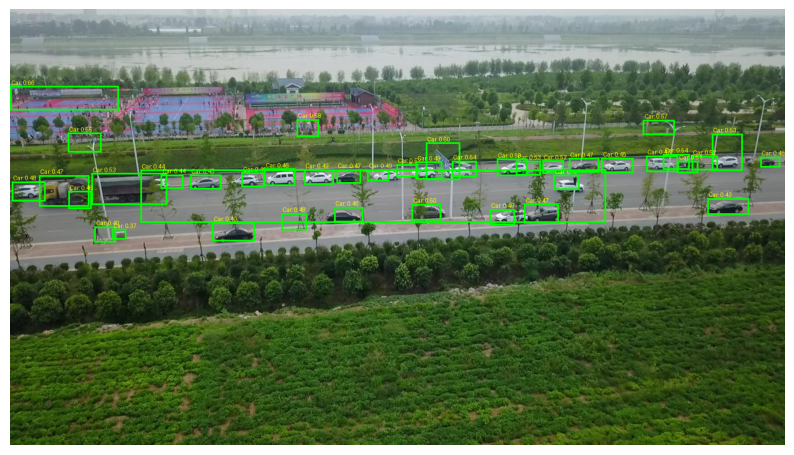

In [9]:

import os
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import torchvision.ops as ops
from transformers import DetrForObjectDetection, DetrImageProcessor

# 1. Load base architecture and map your previous trained weights direct!
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50", 
    num_labels=1, 
    ignore_mismatched_sizes=True
)

# LOADING YOUR PREVIOUS PT FILE AT RUNTIME 🎯
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("best_detr_native.pt", map_location=device))
model.to(device)
model.eval()

print("🎉 Previous Trained Weights Loaded Successfully into NMS Matrix!")

# 2. Path lookup and directory map execution
TARGET_DIR = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"
all_images = sorted([f for f in os.listdir(TARGET_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
TEST_IMAGE_PATH = os.path.join(TARGET_DIR, all_images[0])

# 3. Process image matrix & execute model inference pass
image = Image.open(TEST_IMAGE_PATH).convert("RGB")
w, h = image.size
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-processing with optimized lower threshold for tiny vehicles
processed_results = processor.post_process_object_detection(
    outputs, 
    target_sizes=torch.tensor([[h, w]]).to(device), 
    threshold=0.15
)[0]

boxes = processed_results["boxes"]
scores = processed_results["scores"]

# 4. Apply Non-Maximum Suppression (NMS) to eliminate duplicate overlapping bounding boxes
if len(boxes) > 0:
    keep_indices = ops.nms(boxes, scores, iou_threshold=0.3)
    filtered_boxes = boxes[keep_indices]
    filtered_scores = scores[keep_indices]
else:
    filtered_boxes, filtered_scores = [], []

# 5. Render clean filtered boundary targets
draw = ImageDraw.Draw(image)
print(f"🔥 Active Track Matrix: Displaying {len(filtered_boxes)} stabilized surveillance targets.")

for score, box in zip(filtered_scores, filtered_boxes):
    x0, y0, x1, y1 = [round(i, 2) for i in box.tolist()]
    
    draw.rectangle([x0, y0, x1, y1], outline="lime", width=3)
    text = f"Car: {score.item():.2f}"
    draw.text((x0 + 3, y0 - 12 if y0 > 15 else y0 + 3), text, fill="yellow")

# Display optimized plotting canvas
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

##  Temporal Video Inference Pipeline (Surveillance Video Processor)

In [10]:
## 5. Temporal Video Inference Pipeline (Surveillance Video Processor)
import os
import cv2
import torch
import torchvision.ops as ops
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor

# 1. Device aur Model Architecture Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", num_labels=1, ignore_mismatched_sizes=True)

# Aapke trained native weights ko runtime par load karna
model.load_state_dict(torch.load("best_detr_native.pt", map_location=device))
model.to(device)
model.eval()

# 2. Input aur Output Paths Configure Karein
INPUT_VIDEO_PATH = "traffic.mp4" 
OUTPUT_VIDEO_PATH = "output_traffic_detection.mp4"

if not os.path.exists(INPUT_VIDEO_PATH):
    print(f"❌ Error: Please check if '{INPUT_VIDEO_PATH}' is present in this directory!")
else:
    # 3. OpenCV Video Capture Engine Initialize Karein
    cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 30)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Video Writer configuration setup
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

    print(f"🎬 Processing Video: {INPUT_VIDEO_PATH} ({total_frames} Frames @ {fps} FPS)...")
    print("-" * 65)

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break  # Video khatam hone par loop end hoga
            
        frame_idx += 1
        
        # OpenCV BGR frame ko PIL RGB Image mein convert karein model feed ke liye
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb_frame)
        
        # Model Inference Execution pass
        inputs = processor(images=pil_img, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            
        # Post Processing Matrix Setup with low threshold for small objects
        processed_results = processor.post_process_object_detection(
            outputs, 
            target_sizes=torch.tensor([[height, width]]).to(device), 
            threshold=0.15
        )[0]
        
        boxes = processed_results["boxes"]
        scores = processed_results["scores"]
        
        # Non-Maximum Suppression (NMS) layer mapping duplicate blocks hatane ke liye
        if len(boxes) > 0:
            keep_indices = ops.nms(boxes, scores, iou_threshold=0.3)
            filtered_boxes = boxes[keep_indices]
            filtered_scores = scores[keep_indices]
        else:
            filtered_boxes, filtered_scores = [], []
            
        # 4. Filtered tracking targets ko frame par overlay karna
        for score, box in zip(filtered_scores, filtered_boxes):
            x0, y0, x1, y1 = [int(i) for i in box.tolist()]
            
            # Draw Sharp Lime Green Box (BGR: (0, 255, 0))
            cv2.rectangle(frame, (x0, y0), (x1, y1), (0, 255, 0), 3)
            
            # Draw Yellow Text label overlay
            text = f"Car: {score.item():.2f}"
            cv2.putText(frame, text, (x0 + 3, y0 - 8 if y0 > 15 else y0 + 15), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
                        
        # Stream frame update to output file
        out.write(frame)
        
        if frame_idx % 30 == 0 or frame_idx == total_frames:
            print(f"⚡ Processing Temporal Progress: Frame {frame_idx}/{total_frames} Stacked Successfully.")

    # Memory buffer cleanup operations
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print("-" * 65)
    print(f"💾 SUCCESS: Processed video tracking saved as '{OUTPUT_VIDEO_PATH}'!")

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `91`.
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 9893.72it/s]
[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |         

🎬 Processing Video: traffic.mp4 (383 Frames @ 30 FPS)...
-----------------------------------------------------------------
⚡ Processing Temporal Progress: Frame 30/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 60/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 90/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 120/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 150/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 180/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 210/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 240/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 270/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 300/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 330/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 360/383 Stacked Successfully.
⚡ Processing Temporal Progress: Frame 383/383 Stacked Successful

error: OpenCV(4.10.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


##  Advanced Spatial Surveillance: Intrusion Boundaries & Density Grid Processing

In [11]:
## Advanced Spatial Surveillance: Intrusion Boundaries & Density Grid
import os
import cv2
import torch
import numpy as np
import torchvision.ops as ops
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor

# 1. Device and Model Pipeline Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", num_labels=1, ignore_mismatched_sizes=True)

# Weight verification pass
model.load_state_dict(torch.load("best_detr_native.pt", map_location=device))
model.to(device)
model.eval()

# 2. File Path Definition
INPUT_VIDEO_PATH = "traffic.mp4" 
OUTPUT_VIDEO_PATH = "output_analytics_surveillance.mp4"

if not os.path.exists(INPUT_VIDEO_PATH):
    print(f"❌ Target Error: Context video file '{INPUT_VIDEO_PATH}' not found.")
else:
    cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 30)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Video output stream mapping configuration
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

    # 🚨 DEFINE COORDINATES (Adjust based on your traffic lane layout)
    # Danger Intrusion Zone Polygon (Bottom Left / Center Lane Focus Area)
    intrusion_pts = np.array([
        [int(width * 0.1), int(height * 0.95)],
        [int(width * 0.45), int(height * 0.45)],
        [int(width * 0.65), int(height * 0.45)],
        [int(width * 0.55), int(height * 0.95)]
    ], np.int32)

    print(f"🎬 Initializing Production Analytics Engine on: {INPUT_VIDEO_PATH}...")
    print(f"🔒 Spatial Zones Configured. Analyzing grid...")
    print("-" * 65)

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_idx += 1
        
        # Create an overlay layer for transparent boundary tracking graphics
        overlay = frame.copy()
        
        # Draw Semi-Transparent Red Intrusion Zone Canvas onto overlay
        cv2.fillPoly(overlay, [intrusion_pts], (0, 0, 255))
        # Add 30% alpha blend for the alpha polygon fill mask
        cv2.addWeighted(overlay, 0.25, frame, 0.75, 0, frame)
        # Clean Solid boundary line trace
        cv2.polylines(frame, [intrusion_pts], True, (0, 0, 255), 3)
        
        # Forward passing conversion matrix to PIL RGB format
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb_frame)
        
        inputs = processor(images=pil_img, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            
        processed_results = processor.post_process_object_detection(
            outputs, target_sizes=torch.tensor([[height, width]]).to(device), threshold=0.15
        )[0]
        
        boxes = processed_results["boxes"]
        scores = processed_results["scores"]
        
        if len(boxes) > 0:
            keep_indices = ops.nms(boxes, scores, iou_threshold=0.3)
            filtered_boxes = boxes[keep_indices]
            filtered_scores = scores[keep_indices]
        else:
            filtered_boxes, filtered_scores = [], []

        intrusion_count = 0
        total_detected = len(filtered_boxes)
            
        # 3. Analyze spatial location of bounding matrices
        for score, box in zip(filtered_scores, filtered_boxes):
            x0, y0, x1, y1 = [int(i) for i in box.tolist()]
            
            # Calculate object anchor baseline reference (center point of the vehicle's bottom profile)
            base_x = int((x0 + x1) / 2)
            base_y = int(y1)
            
            # Check if target baseline anchor intersects with the defined polygon perimeter grid
            inside_intrusion = cv2.pointPolygonTest(intrusion_pts, (base_x, base_y), False)
            
            if inside_intrusion >= 0:
                # Target Violation Context Detected (Render Red Alert Matrix)
                intrusion_count += 1
                box_color = (0, 0, 255) # Red Box
                text_label = f"ALERT - CAR: {score.item():.2f}"
                # Draw a warning dot at the intersection vector
                cv2.circle(frame, (base_x, base_y), 6, (0, 0, 255), -1)
            else:
                # Normal State Detected (Render Standard Track Matrix)
                box_color = (0, 255, 0) # Lime Green
                text_label = f"Car: {score.item():.2f}"
            
            # Render Target geometry onto dynamic canvas
            cv2.rectangle(frame, (x0, y0), (x1, y1), box_color, 2)
            cv2.putText(frame, text_label, (x0 + 4, y0 - 8 if y0 > 15 else y0 + 15), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
                        
        # 4. Burn Analytics HUD Info Board directly on upper canvas space
        cv2.rectangle(frame, (15, 15), (420, 115), (0, 0, 0), -1) # Black UI Board
        cv2.putText(frame, f"AI SURVEILLANCE PLATFORM v2.1", (25, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(frame, f"Active Grid Count: {total_detected}", (25, 68), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        cv2.putText(frame, f"Intrusion Violations: {intrusion_count}", (25, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        
        # Write array back to physical storage disk
        out.write(frame)
        
        if frame_idx % 30 == 0 or frame_idx == total_frames:
            print(f"⚡ Processing Surveillance Analytics Frame: {frame_idx}/{total_frames} Frame Sync Complete.")

    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print("-" * 65)
    print(f"💾 SUCCESS: Analytics video output generated and saved as '{OUTPUT_VIDEO_PATH}'!")

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `91`.
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 2750.11it/s]
[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |         

🎬 Initializing Production Analytics Engine on: traffic.mp4...
🔒 Spatial Zones Configured. Analyzing grid...
-----------------------------------------------------------------
⚡ Processing Surveillance Analytics Frame: 30/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 60/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 90/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 120/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 150/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 180/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 210/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 240/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 270/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 300/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics Frame: 330/383 Frame Sync Complete.
⚡ Processing Surveillance Analytics F

error: OpenCV(4.10.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


## App Creation Code

In [12]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
import torch
import os
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor
from streamlit_image_coordinates import streamlit_image_coordinates

# Page context arrangement
st.set_page_config(layout="wide", page_title="AI Surveillance Platform")

st.title("🎯 Live Dynamic Intrusion Guardrails (Interactive Analytics Matrix)")
st.sidebar.title("📊 Security Control Panel")

IMAGE_DIR = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"

if os.path.exists(IMAGE_DIR):
    img_list = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    selected_img = st.sidebar.selectbox("📂 Select Drone Surveillance Feed Image:", img_list if img_list else ["No Images Found"])
    img_path = os.path.join(IMAGE_DIR, selected_img)
else:
    st.error("❌ Production dataset folder path not detected.")
    st.stop()

# Unique session tracking key map
state_key = f"poly_points_{selected_img}"
if state_key not in st.session_state:
    st.session_state[state_key] = []

if st.sidebar.button("🧹 Clear Drawn Alert Zone Points"):
    st.session_state[state_key] = []
    st.rerun()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@st.cache_resource
def load_surveillance_model():
    processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
    model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
    model.to(device)
    model.eval()
    return processor, model

processor, model = load_surveillance_model()
coco_labels = model.config.id2label

# Ray-casting algorithm for polygon boundary containment verification
def is_inside_polygon(x, y, poly):
    num = len(poly)
    j = num - 1
    c = False
    for i in range(num):
        if ((poly[i][1] > y) != (poly[j][1] > y)) and \
                (x < (poly[j][0] - poly[i][0]) * (y - poly[i][1]) / (poly[j][1] - poly[i][1] + 1e-6) + poly[i][0]):
            c = not c
        j = i
    return c

if img_path and os.path.exists(img_path):
    # 1. Image Resolution Normalization Engine
    image_raw = Image.open(img_path).convert("RGB")
    TARGET_WIDTH = 750 
    W_orig, H_orig = image_raw.size
    scale_factor = TARGET_WIDTH / W_orig
    TARGET_HEIGHT = int(H_orig * scale_factor)
    
    # Scale down high-res raw frames tightly
    image_resized = image_raw.resize((TARGET_WIDTH, TARGET_HEIGHT))
    
    # 2. Extract AI Inference Bounding Tensors
    inputs = processor(images=image_resized, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    target_sizes = torch.tensor([[TARGET_HEIGHT, TARGET_WIDTH]]).to(device)
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.25)[0]
    
    # Read CV2 base copy for graphic overlays
    img_cv = cv2.imread(img_path)
    img_cv = cv2.resize(img_cv, (TARGET_WIDTH, TARGET_HEIGHT))
    
    active_points = st.session_state[state_key]
    zone_active = len(active_points) >= 3
    
    # 3. Dynamic Vector Graphics Render
    if zone_active:
        # Create transparent alpha layer for intrusion zone fill mapping
        overlay = img_cv.copy()
        pts = np.array(active_points, np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(overlay, [pts], (0, 0, 255))
        cv2.addWeighted(overlay, 0.2, img_cv, 0.8, 0, img_cv)
        cv2.polylines(img_cv, [pts], True, (0, 0, 255), 2)
    elif len(active_points) > 1:
        pts = np.array(active_points, np.int32).reshape((-1, 1, 2))
        cv2.polylines(img_cv, [pts], False, (0, 165, 255), 2) # Orange guide line
        
    for pt in active_points:
        cv2.circle(img_cv, pt, 5, (0, 0, 255), -1)
        
    violations_inside_zone = []

    # 4. Target Location Analysis and Object Labeling Loop
    for idx, (score, label_id, box) in enumerate(zip(results["scores"], results["labels"], results["boxes"])):
        box_coords = [int(i) for i in box.tolist()]
        cx = int((box_coords[0] + box_coords[2]) / 2)
        cy = int(box_coords[3]) # Anchor vehicle baseline index
        
        class_name = coco_labels.get(int(label_id), "Object").capitalize()
        
        breached = False
        if zone_active:
            breached = is_inside_polygon(cx, cy, active_points)
            
        if breached:
            color = (0, 0, 255) # Red Alert Box for Intrusion Breach
            violations_inside_zone.append(f"🔴 {class_name} #{idx+1:02d} (Conf: {score:.2f})")
            # Render visual alert anchor pin
            cv2.circle(img_cv, (cx, cy), 4, (0, 0, 255), -1)
        else:
            color = (0, 255, 0) # Lime Green Box for Secured Track Targets
            
        cv2.rectangle(img_cv, (box_coords[0], box_coords[1]), (box_coords[2], box_coords[3]), color, 2)
        cv2.putText(img_cv, f"{class_name} {idx+1}", (box_coords[0], max(0, box_coords[1] - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

    # 5. Dual Column UI Render Layout Split
    col1, col2 = st.columns([3, 1])
    
    with col1:
        st.subheader("🖱️ Click on the image below to define custom guardrail coordinates:")
        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        
        # Capture raw frame node clicks safely
        value = streamlit_image_coordinates(img_pil, key="surveillance_canvas")
        
        if value is not None:
            new_point = (value["x"], value["y"])
            # State mutation guardrail validation pass
            if new_point not in st.session_state[state_key]:
                st.session_state[state_key].append(new_point)
                st.rerun()
                
    with col2:
        st.sidebar.metric(label="🚨 Violations in Defined Zone", value=len(violations_inside_zone))
        st.sidebar.subheader("📋 Active Breach Levels:")
        
        if len(active_points) < 3:
            st.sidebar.info("💡 Pro-Tip: Click 3 or more points sequentially on the image grid canvas to seal and activate the dynamic alert zone circuit.")
        elif violations_inside_zone:
            for v_name in violations_inside_zone:
                st.sidebar.error(v_name)
        else:
            st.sidebar.success("✅ Area Secure. Zero Intrusion Breaches.")

Overwriting app.py


## app_video.py

In [6]:
%%writefile app_video.py
import streamlit as st
import cv2
import numpy as np
import torch
import os
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor
from datetime import datetime

# Page Layout Configuration
st.set_page_config(layout="wide", page_title="AI Industrial Surveillance System")

st.title("📹 Industrial Vehicle Surveillance & Guardrail Platform")
st.sidebar.title("📊 Security Command Panel")

# System Session States Setup
base_img_key = "surveillance_base_matrix"
poly_points_key = "guardrail_poly_nodes"
zone_locked_key = "guardrail_is_active"
logs_key = "surveillance_event_logs"

if base_img_key not in st.session_state:
    st.session_state[base_img_key] = None
if poly_points_key not in st.session_state:
    st.session_state[poly_points_key] = []
if zone_locked_key not in st.session_state:
    st.session_state[zone_locked_key] = False
if logs_key not in st.session_state:
    st.session_state[logs_key] = []

# Sidebar System Controls
if st.sidebar.button("🗑️ Full System Reset", type="primary"):
    st.session_state[base_img_key] = None
    st.session_state[poly_points_key] = []
    st.session_state[zone_locked_key] = False
    st.session_state[logs_key] = []
    st.rerun()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@st.cache_resource
def load_surveillance_model():
    processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
    model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
    model.to(device)
    model.eval()
    return processor, model

processor, model = load_surveillance_model()

# Ray-casting containment algorithm engine
def is_inside_polygon(x, y, poly):
    num = len(poly)
    j = num - 1
    c = False
    for i in range(num):
        if ((poly[i][1] > y) != (poly[j][1] > y)) and \
                (x < (poly[j][0] - poly[i][0]) * (y - poly[i][1]) / (poly[j][1] - poly[i][1] + 1e-6) + poly[i][0]):
            c = not c
        j = i
    return c

TARGET_WIDTH = 700
TARGET_HEIGHT = 500

base_matrix = st.session_state[base_img_key]
active_points = st.session_state[poly_points_key]
guardrails_active = st.session_state[zone_locked_key]

# UI Layout Split
col1, col2 = st.columns([2, 1])

# LOGGING PANEL (Normal scope container layout to avoid StreamlitAPIException)
with col2:
    st.sidebar.subheader("🚨 Intrusion Event Logs")
    if guardrails_active:
        if st.session_state[logs_key]:
            for log in reversed(st.session_state[logs_key]):
                st.sidebar.error(log)
        else:
            st.sidebar.info("Surveillance Active: No threats inside zone.")
    else:
        st.sidebar.text("System Logs: Awaiting activation.")

# SURVEILLANCE INTERFACE TERMINAL
with col1:
    viewport_header = st.empty()
    main_viewport = st.empty()
    control_bar = st.empty()

# --- PHASE 1: BASE IMAGE CAPTURE ---
if base_matrix is None:
    viewport_header.subheader("Phase 1: Configure Surveillance Baseline View")
    camera_file = st.camera_input("🎥 Live Camera Baseline Stream")
    
    if control_bar.button("🔒 Capture Surveillance Base Image", type="primary"):
        if camera_file is not None:
            bytes_data = camera_file.getvalue()
            decoded_cv2 = cv2.imdecode(np.frombuffer(bytes_data, np.uint8), cv2.IMREAD_COLOR)
            resized_cv2 = cv2.resize(decoded_cv2, (TARGET_WIDTH, TARGET_HEIGHT))
            st.session_state[base_img_key] = resized_cv2
            st.rerun()
        else:
            st.warning("Please capture an image using the stream first.")

# --- PHASE 2: GUARDRAIL ZONE CONFIGURATION (Frozen Base View) ---
elif base_matrix is not None and not guardrails_active:
    viewport_header.subheader("Phase 2: Configure Custom Perimeter Guardrails (Red Zone)")
    from streamlit_image_coordinates import streamlit_image_coordinates
    
    @st.fragment
    def render_frozen_config_canvas(base_cv2, points):
        display_frame = base_cv2.copy()
        cv2.putText(display_frame, f"Clicked: {len(points)} nodes. Drawing perimeter shape...", (20, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)
        
        if len(points) > 1:
            pts = np.array(points, np.int32).reshape((-1, 1, 2))
            cv2.polylines(display_frame, [pts], False, (255, 165, 0), 2)
            
        for pt in points:
            cv2.circle(display_frame, pt, 6, (0, 255, 255), -1)
            
        img_pil = Image.fromarray(cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB))
        coords = streamlit_image_coordinates(img_pil, key="guardrail_calibration_canvas")
        
        if coords is not None:
            new_pt = (coords["x"], coords["y"])
            if new_pt not in st.session_state[poly_points_key]:
                st.session_state[poly_points_key].append(new_pt)
                st.rerun()

    with main_viewport:
        render_frozen_config_canvas(base_matrix, active_points)
        
    if len(active_points) >= 3:
        if control_bar.button("Activate Live Security Monitoring", type="primary"):
            st.session_state[zone_locked_key] = True
            st.rerun()
    else:
        control_bar.info(f"💡 Click on the base image above to draw your secure boundary area. Current nodes: {len(active_points)}")

# --- PHASE 3: LIVE ACTIVE SURVEILLANCE & EVALUATION (GLITCH & EXCEPTION FREE) ---
elif guardrails_active:
    viewport_header.subheader("Phase 3: Live Industrial Surveillance Active")
    
    # Isolated core detection camera stream fragment (No direct sidebar manipulation inside)
    @st.fragment
    def run_stable_surveillance_pipeline():
        camera_stream = st.camera_input("🎥 Live Active Security Feed", label_visibility="collapsed", key="active_surveillance_stream")
        output_display = st.empty()
        
        if camera_stream is not None:
            stream_bytes = camera_stream.getvalue()
            stream_cv2 = cv2.imdecode(np.frombuffer(stream_bytes, np.uint8), cv2.IMREAD_COLOR)
            active_frame = cv2.resize(stream_cv2, (TARGET_WIDTH, TARGET_HEIGHT))
            
            overlay_mask = active_frame.copy()
            pts_guardrail = np.array(active_points, np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(overlay_mask, [pts_guardrail], (0, 0, 255))
            cv2.addWeighted(overlay_mask, 0.22, active_frame, 0.78, 0, active_frame)
            cv2.polylines(active_frame, [pts_guardrail], True, (0, 0, 255), 2)
            
            active_pil = Image.fromarray(cv2.cvtColor(stream_cv2, cv2.COLOR_BGR2RGB))
            inputs_active = processor(images=active_pil, return_tensors="pt").to(device)
            
            with torch.no_grad():
                outputs_active = model(**inputs_active)
                
            results_active = processor.post_process_object_detection(
                outputs_active, target_sizes=torch.tensor([[TARGET_HEIGHT, TARGET_WIDTH]]).to(device), threshold=0.40
            )[0]
            
            next_obj_id = 1
            current_vehicles_seen = 0
            current_intrusions = 0
            SURVEILLANCE_VEHICLES = [3, 4, 6, 8]
            
            has_new_intrusion = False
            
            for score, label, box in zip(results_active["scores"], results_active["labels"], results_active["boxes"]):
                if label.item() not in SURVEILLANCE_VEHICLES:
                    continue
                    
                box_active = [int(i) for i in box.tolist()]
                current_vehicles_seen += 1
                
                target_cx = int((box_active[0] + box_active[2]) / 2)
                target_cy = int((box_active[1] + box_active[3]) / 2)
                
                label_name = "Vehicle"
                if label.item() == 3: label_name = "Car"
                elif label.item() == 4: label_name = "Motorcycle"
                elif label.item() == 8: label_name = "Truck"
                
                if is_inside_polygon(target_cx, target_cy, active_points):
                    bounding_color = (0, 0, 255)
                    viz_label = f"⚠️ INTRUDER #{next_obj_id} ({label_name})"
                    
                    time_now = datetime.now().strftime("%H:%M:%S")
                    registry_entry = f"[{time_now}] 🚨 {label_name} detected breaching Security Cordon!"
                    if registry_entry not in st.session_state[logs_key]:
                        st.session_state[logs_key].append(registry_entry)
                        has_new_intrusion = True
                        
                    current_intrusions += 1
                    next_obj_id += 1
                else:
                    bounding_color = (0, 255, 0)
                    viz_label = label_name
                    
                cv2.rectangle(active_frame, (box_active[0], box_active[1]), (box_active[2], box_active[3]), bounding_color, 2)
                cv2.putText(active_frame, f"{viz_label} {score:.2f}", (box_active[0], max(0, box_active[1] - 7)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, bounding_color, 2)
                cv2.circle(active_frame, (target_cx, target_cy), 5, bounding_color, -1)
                
            cv2.rectangle(active_frame, (15, 15), (320, 85), (0, 0, 0), -1)
            cv2.putText(active_frame, f"LIVE VEHICLES SEEING: {current_vehicles_seen}", (25, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1)
            cv2.putText(active_frame, f"CURRENT FRAME INTRUSIONS: {current_intrusions}", (25, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)
            
            with output_display:
                st.image(cv2.cvtColor(active_frame, cv2.COLOR_BGR2RGB), use_container_width=True)
            
            # Agar koi nayi intrusion hui hai toh fragment ke bahar trigger bhej kar sidebar update karenge
            if has_new_intrusion:
                st.rerun()

    with main_viewport:
        run_stable_surveillance_pipeline()

Overwriting app_video.py


In [7]:
import streamlit as st
import cv2
import numpy as np
import torch
import os
import time
import psutil
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor
from ultralytics import YOLO
from datetime import datetime
from streamlit_image_coordinates import streamlit_image_coordinates

# Page Layout Configuration
st.set_page_config(layout="wide", page_title="AI Multi-Input Surveillance Platform")

st.title("📹 Advanced Multi-Model Vehicle Surveillance & Guardrail Platform")
st.sidebar.title("📊 Security Command Panel")

# --- STEP 1: GLOBAL INPUT MODE CONFIGURATION ---
input_mode = st.sidebar.radio(
    "📁 Choose Input Source Mode",
    ["Dataset Images Folder", "Upload Static Photo", "Upload Video File", "Live Webcam Stream"]
)

# --- STEP 2: MODEL ARCHITECTURE SELECTOR ---
selected_model_type = st.sidebar.selectbox(
    "🤖 Select AI Detection Architecture",
    ["YOLOv8 (High-Speed CNN)", "DETR (Transformer-Based)"]
)

# Global Dataset Folder Configuration
IMAGE_DIR = "/home/intern/internship_projects/Ipseeta /AI SURVEILLANCE PLATFORM/yolo_dataset/images/train"

# Session Tracking State Keys Allocation
selected_img_name = "default_canvas"
if input_mode == "Dataset Images Folder" and os.path.exists(IMAGE_DIR):
    img_list = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    if img_list:
        selected_img = st.sidebar.selectbox("📂 Select Drone Surveillance Feed Image:", img_list)
        selected_img_name = selected_img
    else:
        st.sidebar.warning("No images found in dataset folder.")
elif input_mode == "Upload Static Photo":
    selected_img_name = "uploaded_photo_matrix"
elif input_mode == "Upload Video File":
    selected_img_name = "uploaded_video_stream"
elif input_mode == "Live Webcam Stream":
    selected_img_name = "live_webcam_stream"

# Matrix States Initializer
base_img_key = f"surveillance_base_matrix_{selected_img_name}"
poly_points_key = f"guardrail_poly_nodes_{selected_img_name}"
zone_locked_key = f"guardrail_is_active_{selected_img_name}"
logs_key = "surveillance_event_logs"

if base_img_key not in st.session_state:
    st.session_state[base_img_key] = None
if poly_points_key not in st.session_state:
    st.session_state[poly_points_key] = []
if zone_locked_key not in st.session_state:
    st.session_state[zone_locked_key] = False
if logs_key not in st.session_state:
    st.session_state[logs_key] = []

# Sidebar Global System Master Reset
if st.sidebar.button("🗑️ Full System Reset", type="primary"):
    for key in list(st.session_state.keys()):
        del st.session_state[key]
    st.rerun()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- CACHED MODEL LOADERS ---
@st.cache_resource
def load_detr_model():
    processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
    model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
    model.to(device)
    model.eval()
    return processor, model

@st.cache_resource
def load_yolo_model():
    model = YOLO("yolov8n.pt") 
    model.to(device)
    return model

# Ray-casting algorithm engine
def is_inside_polygon(x, y, poly):
    num = len(poly)
    j = num - 1
    c = False
    for i in range(num):
        if ((poly[i][1] > y) != (poly[j][1] > y)) and \
                (x < (poly[j][0] - poly[i][0]) * (y - poly[i][1]) / (poly[j][1] - poly[i][1] + 1e-6) + poly[i][0]):
            c = not c
        j = i
    return c

TARGET_WIDTH = 750
TARGET_HEIGHT = 500

# UI Split Mapping Layout
col1, col2 = st.columns([3, 1])

with col2:
    st.sidebar.subheader("🚨 Intrusion Event Logs")
    violations_metrics_placeholder = st.sidebar.empty()
    logs_display_block = st.sidebar.empty()

with col1:
    viewport_header = st.empty()
    performance_metrics_bar = st.empty() 
    main_viewport = st.empty()
    control_bar = st.empty()

# --- PHASE 1: DYNAMIC DATA SOURCE INGESTION ---
if st.session_state[base_img_key] is None:
    viewport_header.subheader(f"Phase 1: Load Surveillance Baseline View ({input_mode})")
    
    if input_mode == "Dataset Images Folder":
        if os.path.exists(IMAGE_DIR) and img_list:
            target_path = os.path.join(IMAGE_DIR, selected_img)
            raw_cv = cv2.imread(target_path)
            st.session_state[base_img_key] = cv2.resize(raw_cv, (TARGET_WIDTH, TARGET_HEIGHT))
            st.rerun()
        else:
            st.error("Dataset folder not found or empty.")
            
    elif input_mode == "Upload Static Photo":
        uploaded_photo = main_viewport.file_uploader("🖼️ Upload Baseline Image File", type=["jpg", "jpeg", "png"])
        if uploaded_photo is not None and control_bar.button("🔒 Lock Uploaded Photo Baseline", type="primary"):
            bytes_data = uploaded_photo.read()
            decoded_cv2 = cv2.imdecode(np.frombuffer(bytes_data, np.uint8), cv2.IMREAD_COLOR)
            st.session_state[base_img_key] = cv2.resize(decoded_cv2, (TARGET_WIDTH, TARGET_HEIGHT))
            st.rerun()
            
    elif input_mode == "Upload Video File":
        uploaded_video = main_viewport.file_uploader("🎞️ Upload Video File for Analysis", type=["mp4", "avi", "mov"])
        if uploaded_video is not None and control_bar.button("🔒 Extract & Lock First Video Frame", type="primary"):
            with open("temp_baseline_video.mp4", "wb") as f:
                f.write(uploaded_video.read())
            cap_temp = cv2.VideoCapture("temp_baseline_video.mp4")
            success, first_frame = cap_temp.read()
            cap_temp.release()
            if success:
                st.session_state[base_img_key] = cv2.resize(first_frame, (TARGET_WIDTH, TARGET_HEIGHT))
                st.rerun()
            else:
                st.error("Could not read video file stream matrix.")
                
    elif input_mode == "Live Webcam Stream":
        camera_file = main_viewport.camera_input("🎥 Live Camera Baseline Stream")
        if control_bar.button("🔒 Capture Webcam Base Image", type="primary"):
            if camera_file is not None:
                bytes_data = camera_file.getvalue()
                decoded_cv2 = cv2.imdecode(np.frombuffer(bytes_data, np.uint8), cv2.IMREAD_COLOR)
                st.session_state[base_img_key] = cv2.resize(decoded_cv2, (TARGET_WIDTH, TARGET_HEIGHT))
                st.rerun()
            else:
                st.warning("Please capture an image using the stream first.")

# --- PHASE 2: INTERACTIVE ALERT ZONE COORDINATES DESIGN ---
elif st.session_state[base_img_key] is not None and not st.session_state[zone_locked_key]:
    viewport_header.subheader("Phase 2: Click on Image Canvas to Draw Secure Boundaries (Red Zone)")
    
    display_frame = st.session_state[base_img_key].copy()
    active_points = st.session_state[poly_points_key]
    
    cv2.putText(display_frame, f"Clicked: {len(active_points)} nodes. Drawing perimeter shape...", (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
    
    if len(active_points) > 1:
        pts = np.array(active_points, np.int32).reshape((-1, 1, 2))
        cv2.polylines(display_frame, [pts], False, (0, 165, 255), 2) # Orange track bounds
        
    for pt in active_points:
        cv2.circle(display_frame, pt, 6, (0, 255, 255), -1)
        
    img_pil = Image.fromarray(cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB))
    
    with main_viewport:
        coords = streamlit_image_coordinates(img_pil, key=f"canvas_click_{selected_img_name}")
        if coords is not None:
            new_pt = (coords["x"], coords["y"])
            if new_pt not in st.session_state[poly_points_key]:
                st.session_state[poly_points_key].append(new_pt)
                st.rerun()
                
    if len(active_points) >= 3:
        if control_bar.button("🔒 Lock Coordinates & Activate Security Circuit", type="primary"):
            st.session_state[zone_locked_key] = True
            st.rerun()
    else:
        control_bar.info(f"💡 Click on the frame area to draw your secure boundary polygon. Current nodes: {len(active_points)}")

# --- PHASE 3: MULTI-INPUT SURVEILLANCE & PERFORMANCE METRICS RUN ---
elif st.session_state[zone_locked_key]:
    viewport_header.subheader(f"Phase 3: Surveillance Active ({selected_model_type} on {input_mode})")
    
    @st.fragment
    def run_production_surveillance_pipeline(model_choice, mode):
        output_display = st.empty()
        stream_cv2 = None
        is_static_input = False
        
        # Runtime resource resolution mapper
        if mode == "Dataset Images Folder" or mode == "Upload Static Photo":
            stream_cv2 = st.session_state[base_img_key].copy()
            is_static_input = True
            
        elif mode == "Upload Video File":
            if 'video_capture_object' not in st.session_state:
                st.session_state.video_capture_object = cv2.VideoCapture("temp_baseline_video.mp4")
            success, v_frame = st.session_state.video_capture_object.read()
            if not success:
                st.session_state.video_capture_object.set(cv2.CAP_PROP_POS_FRAMES, 0)
                success, v_frame = st.session_state.video_capture_object.read()
            if success:
                stream_cv2 = v_frame
                
        elif mode == "Live Webcam Stream":
            camera_stream = st.camera_input("🎥 Active Feed Matrix", label_visibility="collapsed", key="active_runtime_stream")
            if camera_stream is not None:
                stream_bytes = camera_stream.getvalue()
                stream_cv2 = cv2.imdecode(np.frombuffer(stream_bytes, np.uint8), cv2.IMREAD_COLOR)

        if stream_cv2 is not None:
            start_frame_time = time.time()
            active_frame = cv2.resize(stream_cv2, (TARGET_WIDTH, TARGET_HEIGHT))
            active_points = st.session_state[poly_points_key]
            
            # Draw alpha blended custom perimeter shield
            overlay_mask = active_frame.copy()
            pts_guardrail = np.array(active_points, np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(overlay_mask, [pts_guardrail], (0, 0, 255))
            cv2.addWeighted(overlay_mask, 0.20, active_frame, 0.80, 0, active_frame)
            cv2.polylines(active_frame, [pts_guardrail], True, (0, 0, 255), 2)
            
            detected_objects = []
            start_inference = time.time()
            
            # --- MODEL INFERENCE PIPELINES ---
            if "DETR" in model_choice:
                detr_proc, detr_mod = load_detr_model()
                active_pil = Image.fromarray(cv2.cvtColor(active_frame, cv2.COLOR_BGR2RGB))
                inputs_active = detr_proc(images=active_pil, return_tensors="pt").to(device)
                with torch.no_grad():
                    outputs_active = detr_mod(**inputs_active)
                results = detr_proc.post_process_object_detection(
                    outputs_active, target_sizes=torch.tensor([[TARGET_HEIGHT, TARGET_WIDTH]]).to(device), threshold=0.25
                )[0]
                
                ALLOWED_VEHICLES = {3: "Car", 4: "Motorcycle", 6: "Bus", 8: "Truck", 1: "Person"}
                for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
                    lbl_id = label.item()
                    if lbl_id in ALLOWED_VEHICLES:
                        box_coords = [int(i) for i in box.tolist()]
                        detected_objects.append((box_coords, ALLOWED_VEHICLES[lbl_id], score.item()))
            else:
                yolo_mod = load_yolo_model()
                yolo_results = yolo_mod.predict(active_frame, conf=0.20, verbose=False, device=device)[0]
                
                for box in yolo_results.boxes:
                    cls_id = int(box.cls[0].item())
                    class_name = yolo_mod.names[cls_id].capitalize()
                    allowed_classes = ['person', 'car', 'truck', 'bus', 'motorcycle', 'bicycle']
                    if class_name.lower() in allowed_classes:
                        box_coords = [int(i) for i in box.xyxy[0].tolist()]
                        score = box.conf[0].item()
                        detected_objects.append((box_coords, class_name, score))

            end_inference = time.time()
            latency_ms = (end_inference - start_inference) * 1000
            
            fps = 1 / (time.time() - start_frame_time) if not is_static_input else 0.0
            cpu_usage = psutil.cpu_percent()

            # Dynamic Hardware Metrics Display Render
            with performance_metrics_bar.container():
                m_col1, m_col2, m_col3 = st.columns(3)
                m_col1.metric(label="🚀 Execution Speed", value="Static Mode" if is_static_input else f"{fps:.1f} FPS")
                m_col2.metric(label="⏱️ Inference Latency", value=f"{latency_ms:.1f} ms")
                m_col3.metric(label="💻 CPU Utilization", value=f"{cpu_usage:.1f} %")

            violations_inside_zone = []
            current_intrusions = 0
            has_new_intrusion = False
            
            for idx, (box_active, label_name, score) in enumerate(detected_objects):
                cx = int((box_active[0] + box_active[2]) / 2)
                cy = int(box_active[3]) # Bottom anchor verification index 
                
                breached = is_inside_polygon(cx, cy, active_points)
                if breached:
                    bounding_color = (0, 0, 255) # Red Alert Bounds
                    viz_label = f"⚠️ INTRUDER #{current_intrusions+1} ({label_name})"
                    
                    time_now = datetime.now().strftime("%H:%M:%S")
                    registry_entry = f"[{time_now}] 🚨 {label_name} ({model_choice.split()[0]}) breached Cordon!"
                    if registry_entry not in st.session_state[logs_key]:
                        st.session_state[logs_key].append(registry_entry)
                        has_new_intrusion = True
                    
                    violations_inside_zone.append(f"🔴 {label_name} #{idx+1:02d} (Conf: {score:.2f})")
                    current_intrusions += 1
                else:
                    bounding_color = (0, 255, 255) # Yellow Secure target lines
                    viz_label = label_name
                    
                cv2.rectangle(active_frame, (box_active[0], box_active[1]), (box_active[2], box_active[3]), bounding_color, 2)
                cv2.putText(active_frame, f"{viz_label} {score:.2f}", (box_active[0], max(0, box_active[1] - 7)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, bounding_color, 2)
                cv2.circle(active_frame, (cx, cy), 5, bounding_color, -1)
                
            # Sidebar alerts injection sync
            violations_metrics_placeholder.metric(label="🚨 Violations in Defined Zone", value=current_intrusions)
            with logs_display_block.container():
                if violations_inside_zone:
                    for v_name in violations_inside_zone:
                        st.error(v_name)
                else:
                    st.success("✅ Area Secure. Zero Breaches.")

            with output_display:
                st.image(cv2.cvtColor(active_frame, cv2.COLOR_BGR2RGB), use_container_width=True)
                
            if has_new_intrusion or not is_static_input:
                st.rerun()

    with main_viewport:
        run_production_surveillance_pipeline(selected_model_type, input_mode)

/home/intern/internship_projects/.common_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-07 16:17:51.741 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-07 16:17:51.743 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-07 16:17:51.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-07 16:17:51.758 
  command:

    streamlit run /home/intern/internship_projects/.common_venv/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-07-07 16:17:51.760 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-07 16:17:51.760 Thread 'MainThread': missing